---
## Section 1: Import Libraries

All packages imported with graceful fallbacks. The notebook proceeds even without optional libraries.

In [7]:
import nltk

nltk.data.path.append(r"C:\nltk_data")

from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))

print("Success:", len(STOP_WORDS))

Success: 198


In [4]:
# =============================================================================
# SECTION 1: IMPORT LIBRARIES & ENVIRONMENT SETUP
# =============================================================================

# =============================================================================
# General Libraries
# =============================================================================
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


# =============================================================================
# Reproducibility
# =============================================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


# =============================================================================
# Visualization Libraries
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False
})

PALETTE = [
    "#2E75B6",
    "#1F4E79",
    "#0F6E56",
    "#27AE60",
    "#E67E22",
    "#C0392B"
]


# =============================================================================
# NLP Libraries (NLTK)
# =============================================================================
import nltk

# Manual NLTK data location
nltk.data.path.append(r"C:\nltk_data")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words("english"))

print("✓ NLTK loaded successfully")
print(f"✓ Stopwords loaded: {len(STOP_WORDS)}")


# =============================================================================
# WordCloud
# =============================================================================
try:
    from wordcloud import WordCloud
    WORDCLOUD = True
    print("✓ WordCloud available")

except ImportError:
    WORDCLOUD = False
    print("⚠ WordCloud not installed")


# =============================================================================
# Scikit-Learn Machine Learning Libraries
# =============================================================================
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    label_binarize
)

from sklearn.feature_extraction.text import TfidfVectorizer

# Traditional ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Sampling and Pipeline
from sklearn.utils import resample
from sklearn.pipeline import Pipeline


# =============================================================================
# Evaluation Metrics
# =============================================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)

from scipy.special import softmax as sp_softmax


print("✓ Scikit-learn loaded successfully")


# =============================================================================
# XGBoost
# =============================================================================
try:
    from xgboost import XGBClassifier
    
    XGB = True
    print("✓ XGBoost available")

except ImportError:
    XGB = False
    print("⚠ XGBoost not installed")


# =============================================================================
# TensorFlow / Keras (LSTM, BiLSTM)
# =============================================================================
try:
    import tensorflow as tf

    tf.random.set_seed(SEED)

    from tensorflow.keras.preprocessing.text import Tokenizer as KTok
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    from tensorflow.keras.models import Sequential

    from tensorflow.keras.layers import (
        Embedding,
        LSTM as KLSTM,
        Bidirectional,
        Dense,
        Dropout
    )

    from tensorflow.keras.callbacks import (
        EarlyStopping,
        ReduceLROnPlateau
    )

    TF = True

    print(f"✓ TensorFlow {tf.__version__}")
    print(f"✓ TensorFlow GPU: {tf.config.list_physical_devices('GPU')}")


except ImportError:
    TF = False
    print("⚠ TensorFlow not installed")


# =============================================================================
# PyTorch + HuggingFace Transformers
# =============================================================================
try:
    import torch

    torch.manual_seed(SEED)

    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        get_linear_schedule_with_warmup
    )

    from torch.utils.data import (
        Dataset,
        DataLoader
    )


    TORCH = True

    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    print(f"✓ PyTorch {torch.__version__}")
    print(f"✓ Device: {DEVICE}")


except ImportError:

    TORCH = False
    DEVICE = None

    print("⚠ PyTorch/Transformers not installed")


# =============================================================================
# SHAP Explainable AI
# =============================================================================
try:
    import shap

    SHAP = True

    print(f"✓ SHAP {shap.__version__}")


except ImportError:

    SHAP = False

    print("⚠ SHAP not installed")


# =============================================================================
# LIME Explainable AI
# =============================================================================
try:
    from lime.lime_text import LimeTextExplainer

    LIME = True

    print("✓ LIME available")


except ImportError:

    LIME = False

    print("⚠ LIME not installed")


# =============================================================================
# Environment Summary
# =============================================================================

print("\n" + "="*70)
print("ENVIRONMENT SETUP COMPLETED")
print("="*70)

print(f"Random Seed : {SEED}")
print(f"TensorFlow  : {'Available' if TF else 'Not Available'}")
print(f"PyTorch     : {'Available' if TORCH else 'Not Available'}")
print(f"XGBoost     : {'Available' if XGB else 'Not Available'}")
print(f"WordCloud   : {'Available' if WORDCLOUD else 'Not Available'}")
print(f"SHAP        : {'Available' if SHAP else 'Not Available'}")
print(f"LIME        : {'Available' if LIME else 'Not Available'}")

print("="*70)
print("✓ All imports completed successfully")
print("="*70)

✓ NLTK loaded successfully
✓ Stopwords loaded: 198
✓ WordCloud available
✓ Scikit-learn loaded successfully
✓ XGBoost available
✓ TensorFlow 2.21.0
✓ TensorFlow GPU: []
✓ PyTorch 2.12.1+cpu
✓ Device: cpu
✓ SHAP 0.52.0
✓ LIME available

ENVIRONMENT SETUP COMPLETED
Random Seed : 42
TensorFlow  : Available
PyTorch     : Available
XGBoost     : Available
WordCloud   : Available
SHAP        : Available
LIME        : Available
✓ All imports completed successfully


In [5]:
# 2.1 Load source dataset
import pandas as pd

df_raw = pd.read_csv("balanced_dataset.csv")

print(df_raw.shape)

df_raw.head()

print('=' * 65)
print('DATA QUALITY AUDIT')
print('=' * 65)
print(f'  Shape         : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'  Columns       : {df_raw.columns.tolist()}')
print(f'  Missing vals  : {df_raw.isnull().sum().sum()}')

dup_clean  = df_raw.duplicated(subset=['clean_text']).sum()
dup_exact  = df_raw.duplicated().sum()
print(f'\n  DUPLICATE ANALYSIS:')
print(f'  Exact duplicate rows     : {dup_exact:,}')
print(f'  Duplicate on clean_text  : {dup_clean:,}')

cross = df_raw.groupby('clean_text')['label'].nunique()
cross_multi = (cross > 1).sum()
print(f'  Same text in >1 class    : {cross_multi:,}')

print('\n  CLASS DISTRIBUTION (raw):')
for cls, cnt in df_raw['label'].value_counts().sort_index().items():
    print(f'    {cls:<28}: {cnt:,}')

# Leakage verdict
print('\n  AUDIT VERDICT:')
print(f'  [ISSUE] {dup_clean:,} duplicate clean_text rows detected.')
print('  [ISSUE] Duplicates created by resample(replace=True) on full dataset.')
print('  [ISSUE] With 80/20 split, duplicated tweets contaminate test set.')
print('  [ISSUE] Explains inflated results: SVM=97.6%, RF=97.3%.')
print('  [FIX]   Remove duplicates -> split -> balance training only.')


(22476, 4)
DATA QUALITY AUDIT
  Shape         : 22,476 rows x 4 columns
  Columns       : ['text', 'label', 'clean_text', 'label_encoded']
  Missing vals  : 0

  DUPLICATE ANALYSIS:
  Exact duplicate rows     : 11,240
  Duplicate on clean_text  : 11,309
  Same text in >1 class    : 0

  CLASS DISTRIBUTION (raw):
    atypical                    : 3,746
    bipolar                     : 3,746
    major depressive            : 3,746
    no                          : 3,746
    postpartum_depression       : 3,746
    psychotic                   : 3,746

  AUDIT VERDICT:
  [ISSUE] 11,309 duplicate clean_text rows detected.
  [ISSUE] Duplicates created by resample(replace=True) on full dataset.
  [ISSUE] With 80/20 split, duplicated tweets contaminate test set.
  [ISSUE] Explains inflated results: SVM=97.6%, RF=97.3%.
  [FIX]   Remove duplicates -> split -> balance training only.


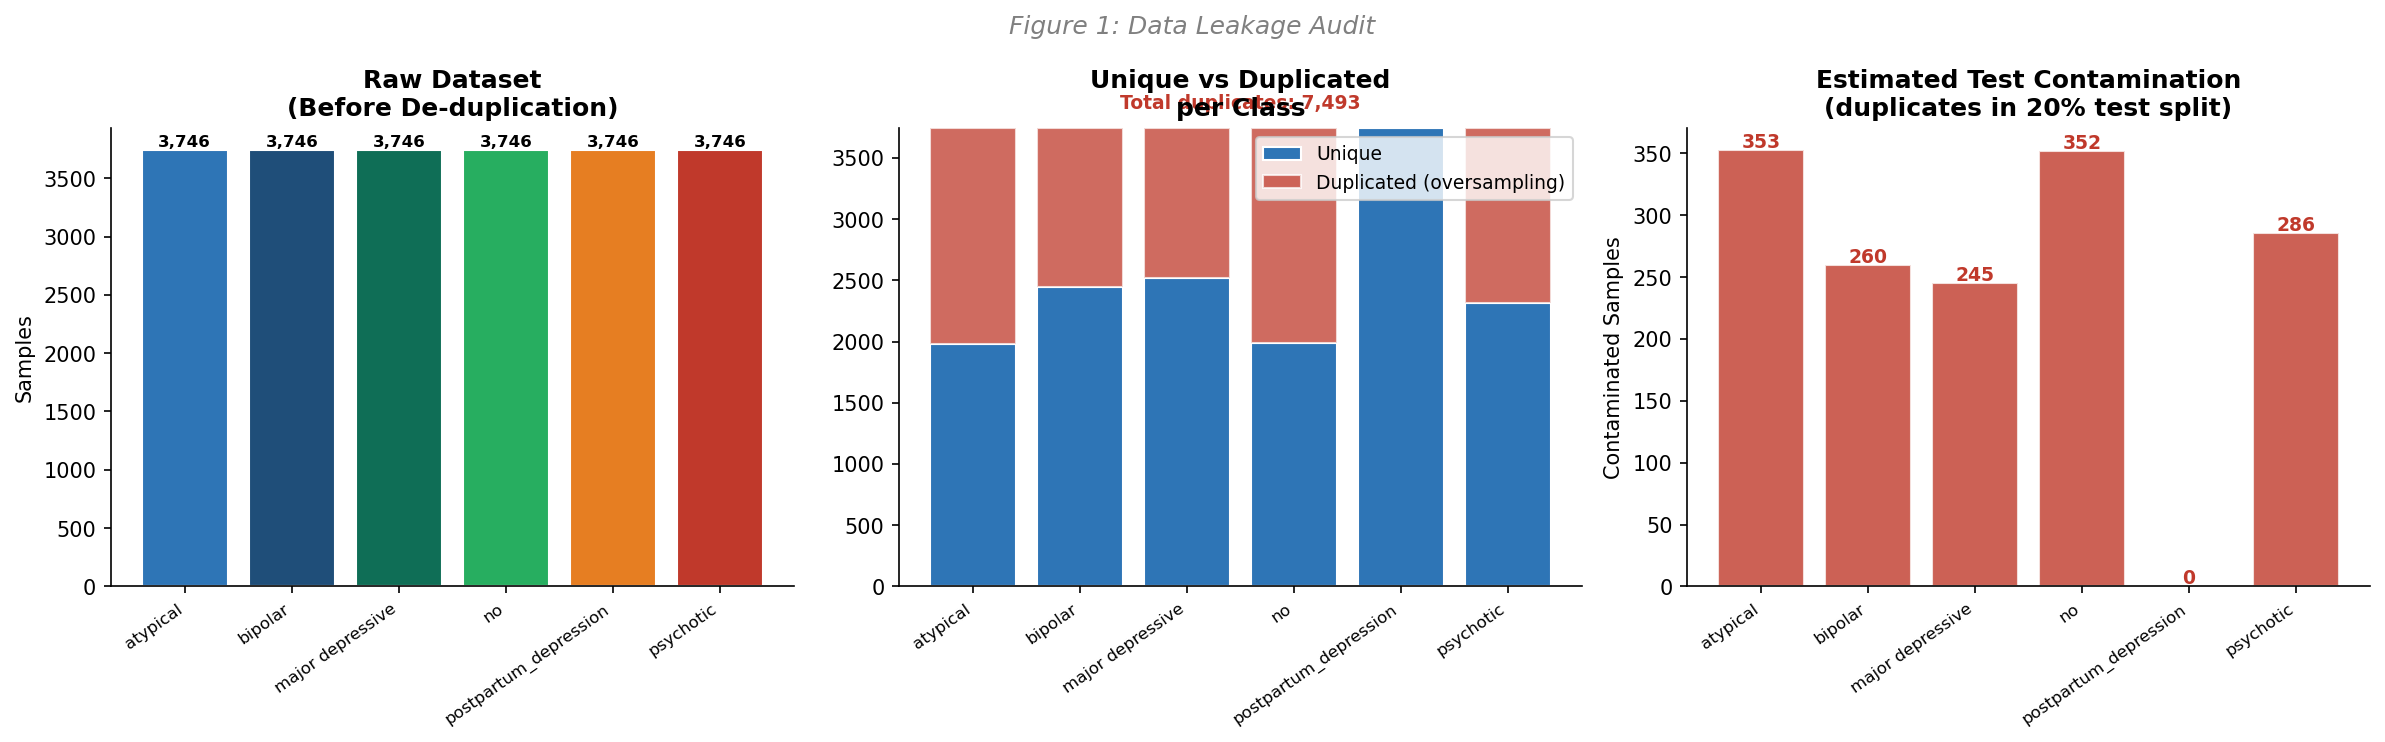

Estimated test contamination: ~1496 samples across all classes


In [6]:
# 2.2 Visualise leakage audit
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Raw class distribution
raw_cls = df_raw['label'].value_counts().sort_index()
axes[0].bar(range(len(raw_cls)), raw_cls.values, color=PALETTE, edgecolor='white')
axes[0].set_xticks(range(len(raw_cls)))
axes[0].set_xticklabels(raw_cls.index, rotation=35, ha='right', fontsize=8)
axes[0].set_title('Raw Dataset\n(Before De-duplication)', fontweight='bold')
axes[0].set_ylabel('Samples')
for i, v in enumerate(raw_cls.values):
    axes[0].text(i, v+30, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

# Plot 2: Unique vs duplicated breakdown
orig_unique = {'atypical':1980,'bipolar':2443,'major depressive':2517,
               'no':1985,'postpartum_depression':3746,'psychotic':2312}
labels_ord = sorted(orig_unique.keys())
uniq_v = [orig_unique[l] for l in labels_ord]
dup_v  = [3746 - orig_unique[l] for l in labels_ord]
x = range(len(labels_ord))
axes[1].bar(x, uniq_v, color='#2E75B6', label='Unique', edgecolor='white')
axes[1].bar(x, dup_v, bottom=uniq_v, color='#C0392B', alpha=0.75,
            label='Duplicated (oversampling)', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels_ord, rotation=35, ha='right', fontsize=8)
axes[1].set_title('Unique vs Duplicated\nper Class', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].text(2.5, 3900, 'Total duplicates: 7,493', ha='center',
             fontsize=9, color='#C0392B', fontweight='bold')

# Plot 3: Estimated test contamination
test_cont = [int((3746-orig_unique[l])*0.2) for l in labels_ord]
axes[2].bar(range(len(labels_ord)), test_cont, color='#C0392B', alpha=0.8, edgecolor='white')
axes[2].set_xticks(range(len(labels_ord)))
axes[2].set_xticklabels(labels_ord, rotation=35, ha='right', fontsize=8)
axes[2].set_title('Estimated Test Contamination\n(duplicates in 20% test split)', fontweight='bold')
axes[2].set_ylabel('Contaminated Samples')
for i, v in enumerate(test_cont):
    axes[2].text(i, v+2, str(v), ha='center', fontsize=9, fontweight='bold', color='#C0392B')

plt.suptitle('Figure 1: Data Leakage Audit', fontsize=12, style='italic', color='grey')
plt.tight_layout()
plt.savefig('fig01_leakage_audit.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Estimated test contamination: ~{sum(test_cont)} samples across all classes')


---
## Section 3: Data Cleaning and De-duplication

All duplicate `clean_text` entries are removed, keeping only the first occurrence. This produces the true unique dataset for modelling.

In [7]:
# 3.1 Remove duplicates
df = df_raw.copy()
df['clean_text'] = df['clean_text'].fillna('').str.strip()
df = df[df['clean_text'].str.len() > 5].copy()

before = len(df)
df = df.drop_duplicates(subset=['clean_text'], keep='first').reset_index(drop=True)
after  = len(df)

print(f'Rows before de-duplication : {before:,}')
print(f'Rows after  de-duplication : {after:,}')
print(f'Duplicates removed         : {before - after:,}')

# Class distribution after de-dup
print('\nClass distribution AFTER de-duplication:')
cls_after = df['label'].value_counts().sort_index()
for cls, cnt in cls_after.items():
    print(f'  {cls:<28}: {cnt:,}')

imbalance = cls_after.max() / cls_after.min()
print(f'\nTotal unique: {after:,} | Imbalance ratio: {imbalance:.2f}')

# Label encoding
CLASS_NAMES = sorted(df['label'].unique().tolist())
NUM_CLASSES  = len(CLASS_NAMES)
le = LabelEncoder()
le.fit(CLASS_NAMES)
print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')
print('Label encoding map:')
for name, code in zip(le.classes_, range(NUM_CLASSES)):
    print(f'  {name:<28} -> {code}')


Rows before de-duplication : 22,474
Rows after  de-duplication : 11,166
Duplicates removed         : 11,308

Class distribution AFTER de-duplication:
  atypical                    : 1,608
  bipolar                     : 1,873
  major depressive            : 1,902
  no                          : 1,643
  postpartum_depression       : 2,326
  psychotic                   : 1,814

Total unique: 11,166 | Imbalance ratio: 1.45

Classes (6): ['atypical', 'bipolar', 'major depressive', 'no', 'postpartum_depression', 'psychotic']
Label encoding map:
  atypical                     -> 0
  bipolar                      -> 1
  major depressive             -> 2
  no                           -> 3
  postpartum_depression        -> 4
  psychotic                    -> 5



## Section 4: Exploratory Data Analysis


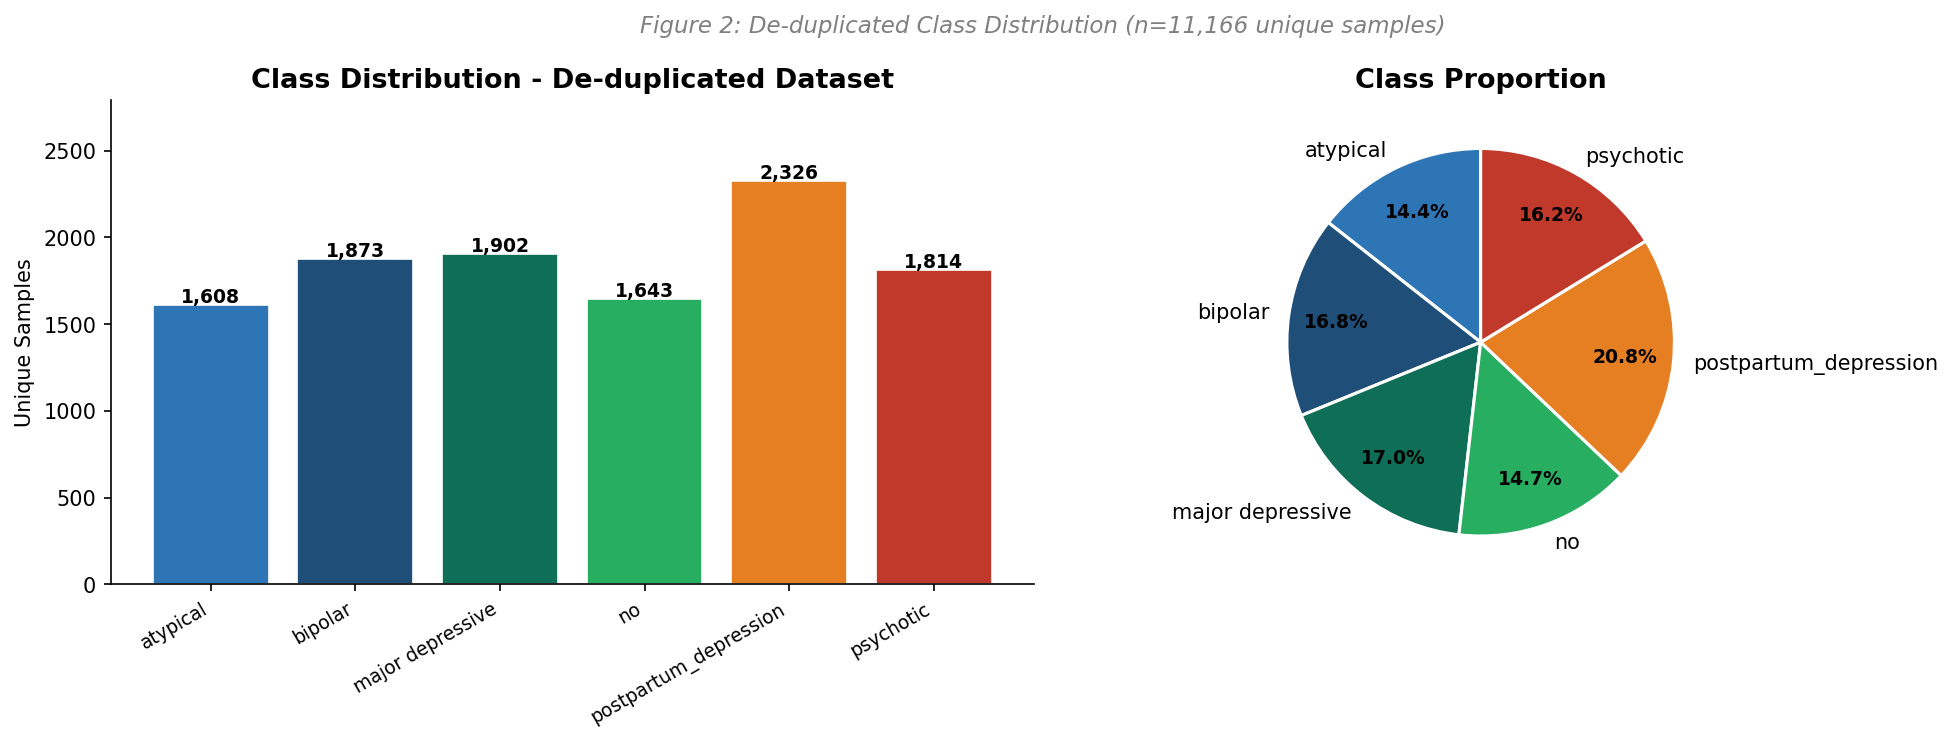

In [8]:
# 4.1 Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cls_counts = df['label'].value_counts().sort_index()

bars = axes[0].bar(range(len(cls_counts)), cls_counts.values,
                   color=PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_xticks(range(len(cls_counts)))
axes[0].set_xticklabels(cls_counts.index, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Class Distribution - De-duplicated Dataset', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Unique Samples')
for bar, val in zip(bars, cls_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(cls_counts.values)*1.2)

wedges, texts, autotexts = axes[1].pie(
    cls_counts.values, labels=cls_counts.index, autopct='%1.1f%%',
    colors=PALETTE, startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontweight='bold', fontsize=13)

plt.suptitle(f'Figure 2: De-duplicated Class Distribution (n={after:,} unique samples)',
             fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.savefig('fig02_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


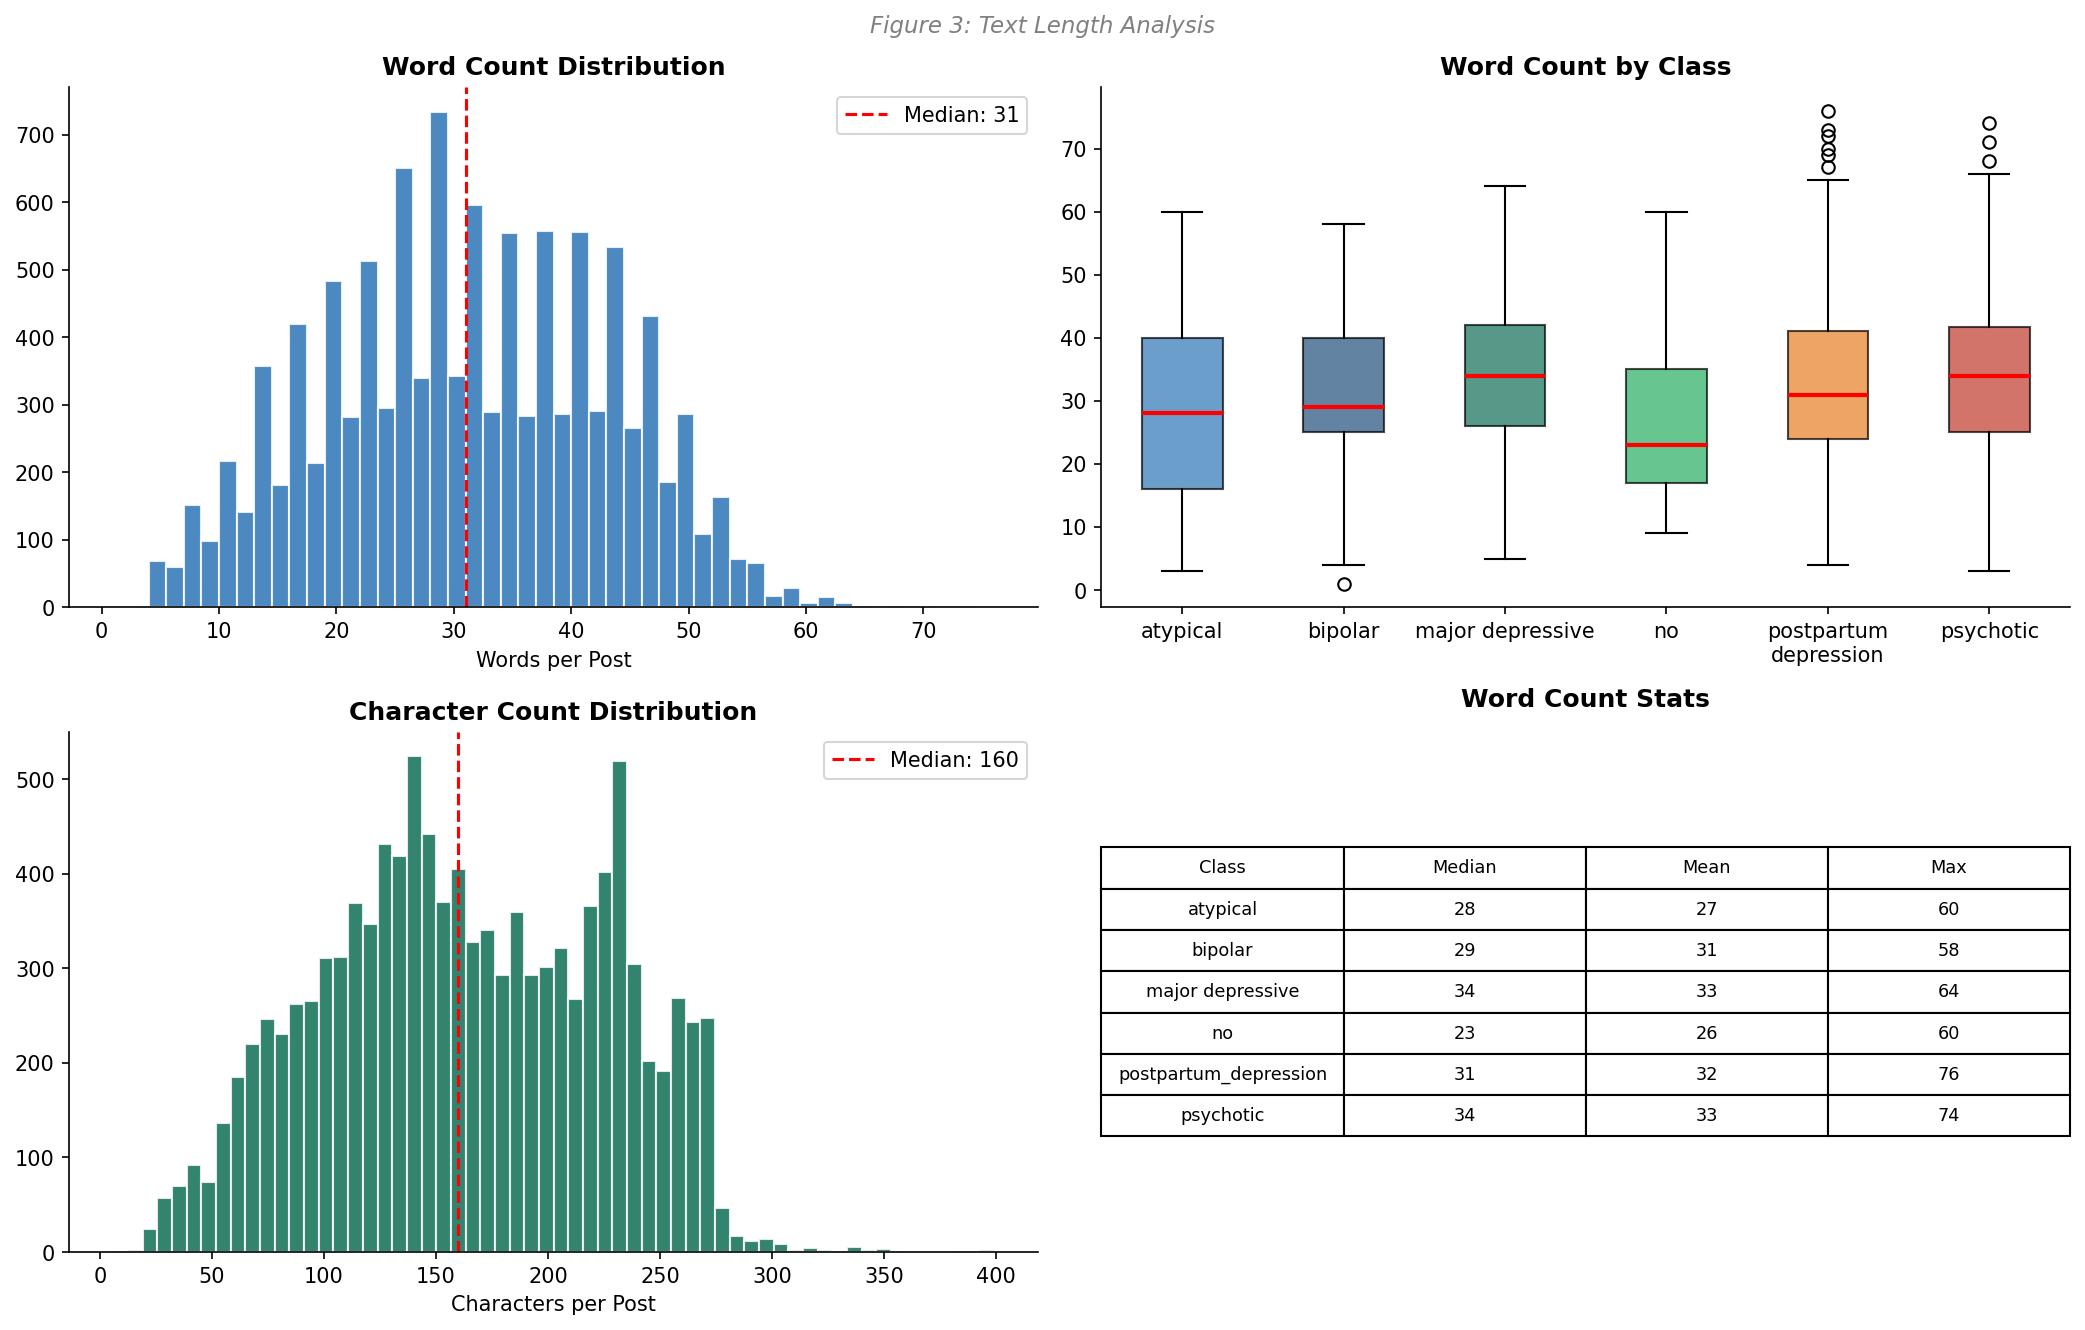

In [9]:
# 4.2 Text length analysis
df['word_count'] = df['clean_text'].str.split().str.len()
df['char_count'] = df['clean_text'].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].hist(df['word_count'], bins=50, color='#2E75B6', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['word_count'].median(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Median: {df['word_count'].median():.0f}")
axes[0,0].set_title('Word Count Distribution', fontweight='bold')
axes[0,0].set_xlabel('Words per Post'); axes[0,0].legend()

data_by_cls = [df[df['label']==c]['word_count'].values for c in CLASS_NAMES]
bp = axes[0,1].boxplot(data_by_cls, labels=[c.replace('_','\n') for c in CLASS_NAMES],
                        patch_artist=True, medianprops=dict(color='red',linewidth=2))
for patch, col in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[0,1].set_title('Word Count by Class', fontweight='bold')

axes[1,0].hist(df['char_count'], bins=60, color='#0F6E56', edgecolor='white', alpha=0.85)
axes[1,0].axvline(df['char_count'].median(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Median: {df['char_count'].median():.0f}")
axes[1,0].set_title('Character Count Distribution', fontweight='bold')
axes[1,0].set_xlabel('Characters per Post'); axes[1,0].legend()

stats_data = [[c, int(df[df['label']==c]['word_count'].median()),
               int(df[df['label']==c]['word_count'].mean()),
               int(df[df['label']==c]['word_count'].max())] for c in CLASS_NAMES]
axes[1,1].axis('off')
tbl = axes[1,1].table(cellText=stats_data,
    colLabels=['Class','Median','Mean','Max'], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.5)
axes[1,1].set_title('Word Count Stats', fontweight='bold', pad=12)

plt.suptitle('Figure 3: Text Length Analysis', fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.savefig('fig03_text_length.png', bbox_inches='tight', dpi=150)
plt.show()


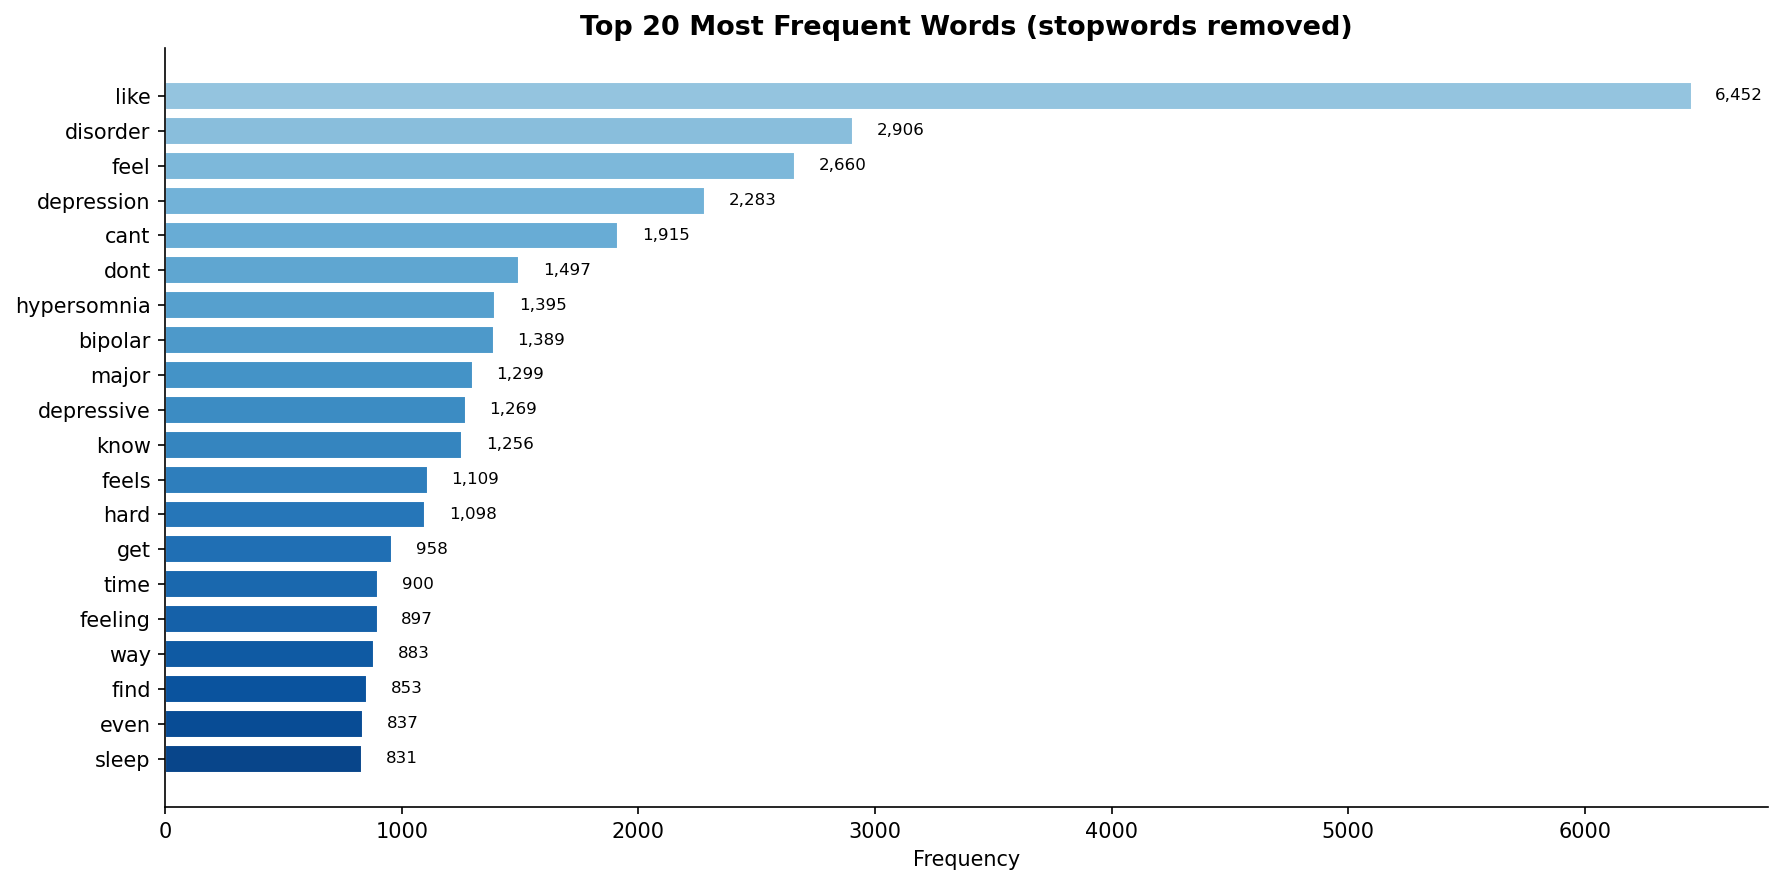

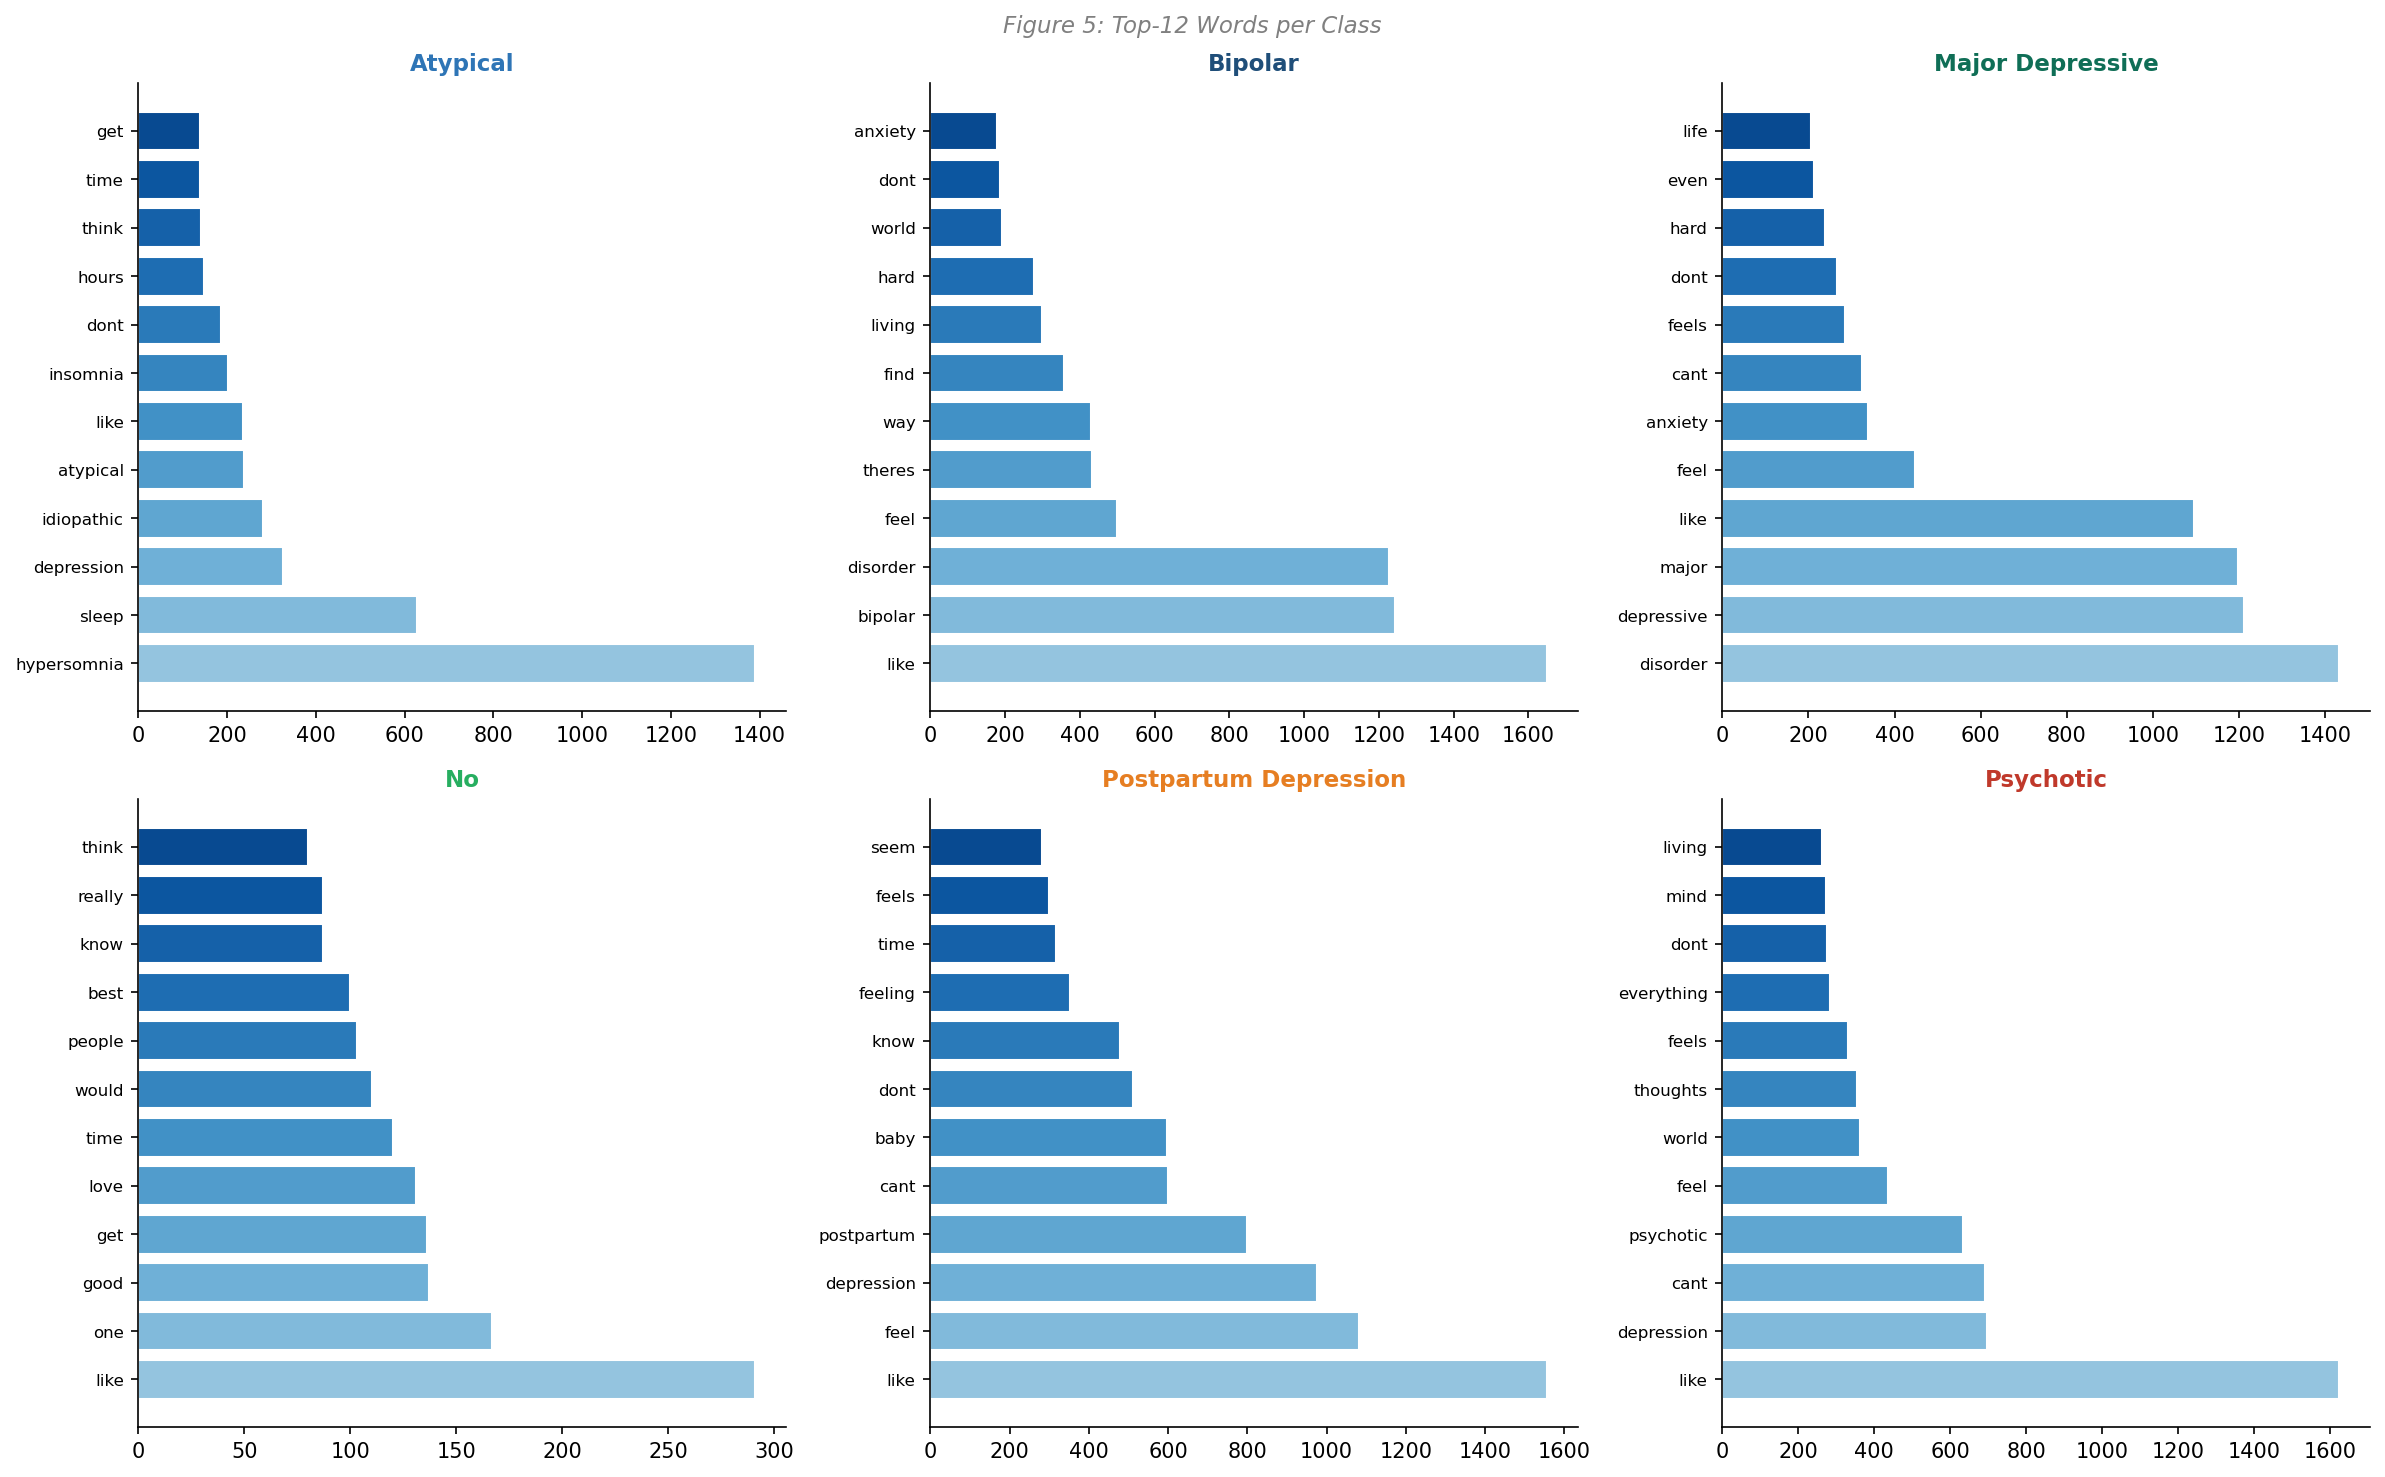

In [10]:
# 4.3 Top-20 words
def get_top_words(texts, n=20):
    words = []
    for t in texts:
        words.extend([w for w in str(t).lower().split()
                      if w.isalpha() and w not in STOP_WORDS and len(w)>2])
    return Counter(words).most_common(n)

top20 = get_top_words(df['clean_text'])
words, freqs = zip(*top20)
fig, ax = plt.subplots(figsize=(12, 6))
cols = plt.cm.Blues(np.linspace(0.4, 0.92, 20))[::-1]
ax.barh(list(words)[::-1], list(freqs)[::-1], color=cols, edgecolor='white')
ax.set_title('Top 20 Most Frequent Words (stopwords removed)', fontweight='bold', fontsize=13)
ax.set_xlabel('Frequency')
for i, f in enumerate(list(freqs)[::-1]):
    ax.text(f+100, i, f'{f:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig04_top20words.png', bbox_inches='tight', dpi=150)
plt.show()

# Per-class top words
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (cls, ax) in enumerate(zip(CLASS_NAMES, axes.flatten())):
    top = get_top_words(df[df['label']==cls]['clean_text'], 12)
    if top:
        ws, fs = zip(*top)
        ax.barh(range(len(ws)), list(fs)[::-1],
                color=plt.cm.Blues(np.linspace(0.4,0.9,len(ws)))[::-1], edgecolor='white')
        ax.set_yticks(range(len(ws)))
        ax.set_yticklabels(list(ws)[::-1], fontsize=8)
    ax.set_title(cls.replace('_',' ').title(), fontweight='bold', fontsize=11, color=PALETTE[idx])
    ax.invert_yaxis()
plt.suptitle('Figure 5: Top-12 Words per Class', fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.savefig('fig05_perclass_words.png', bbox_inches='tight', dpi=150)
plt.show()


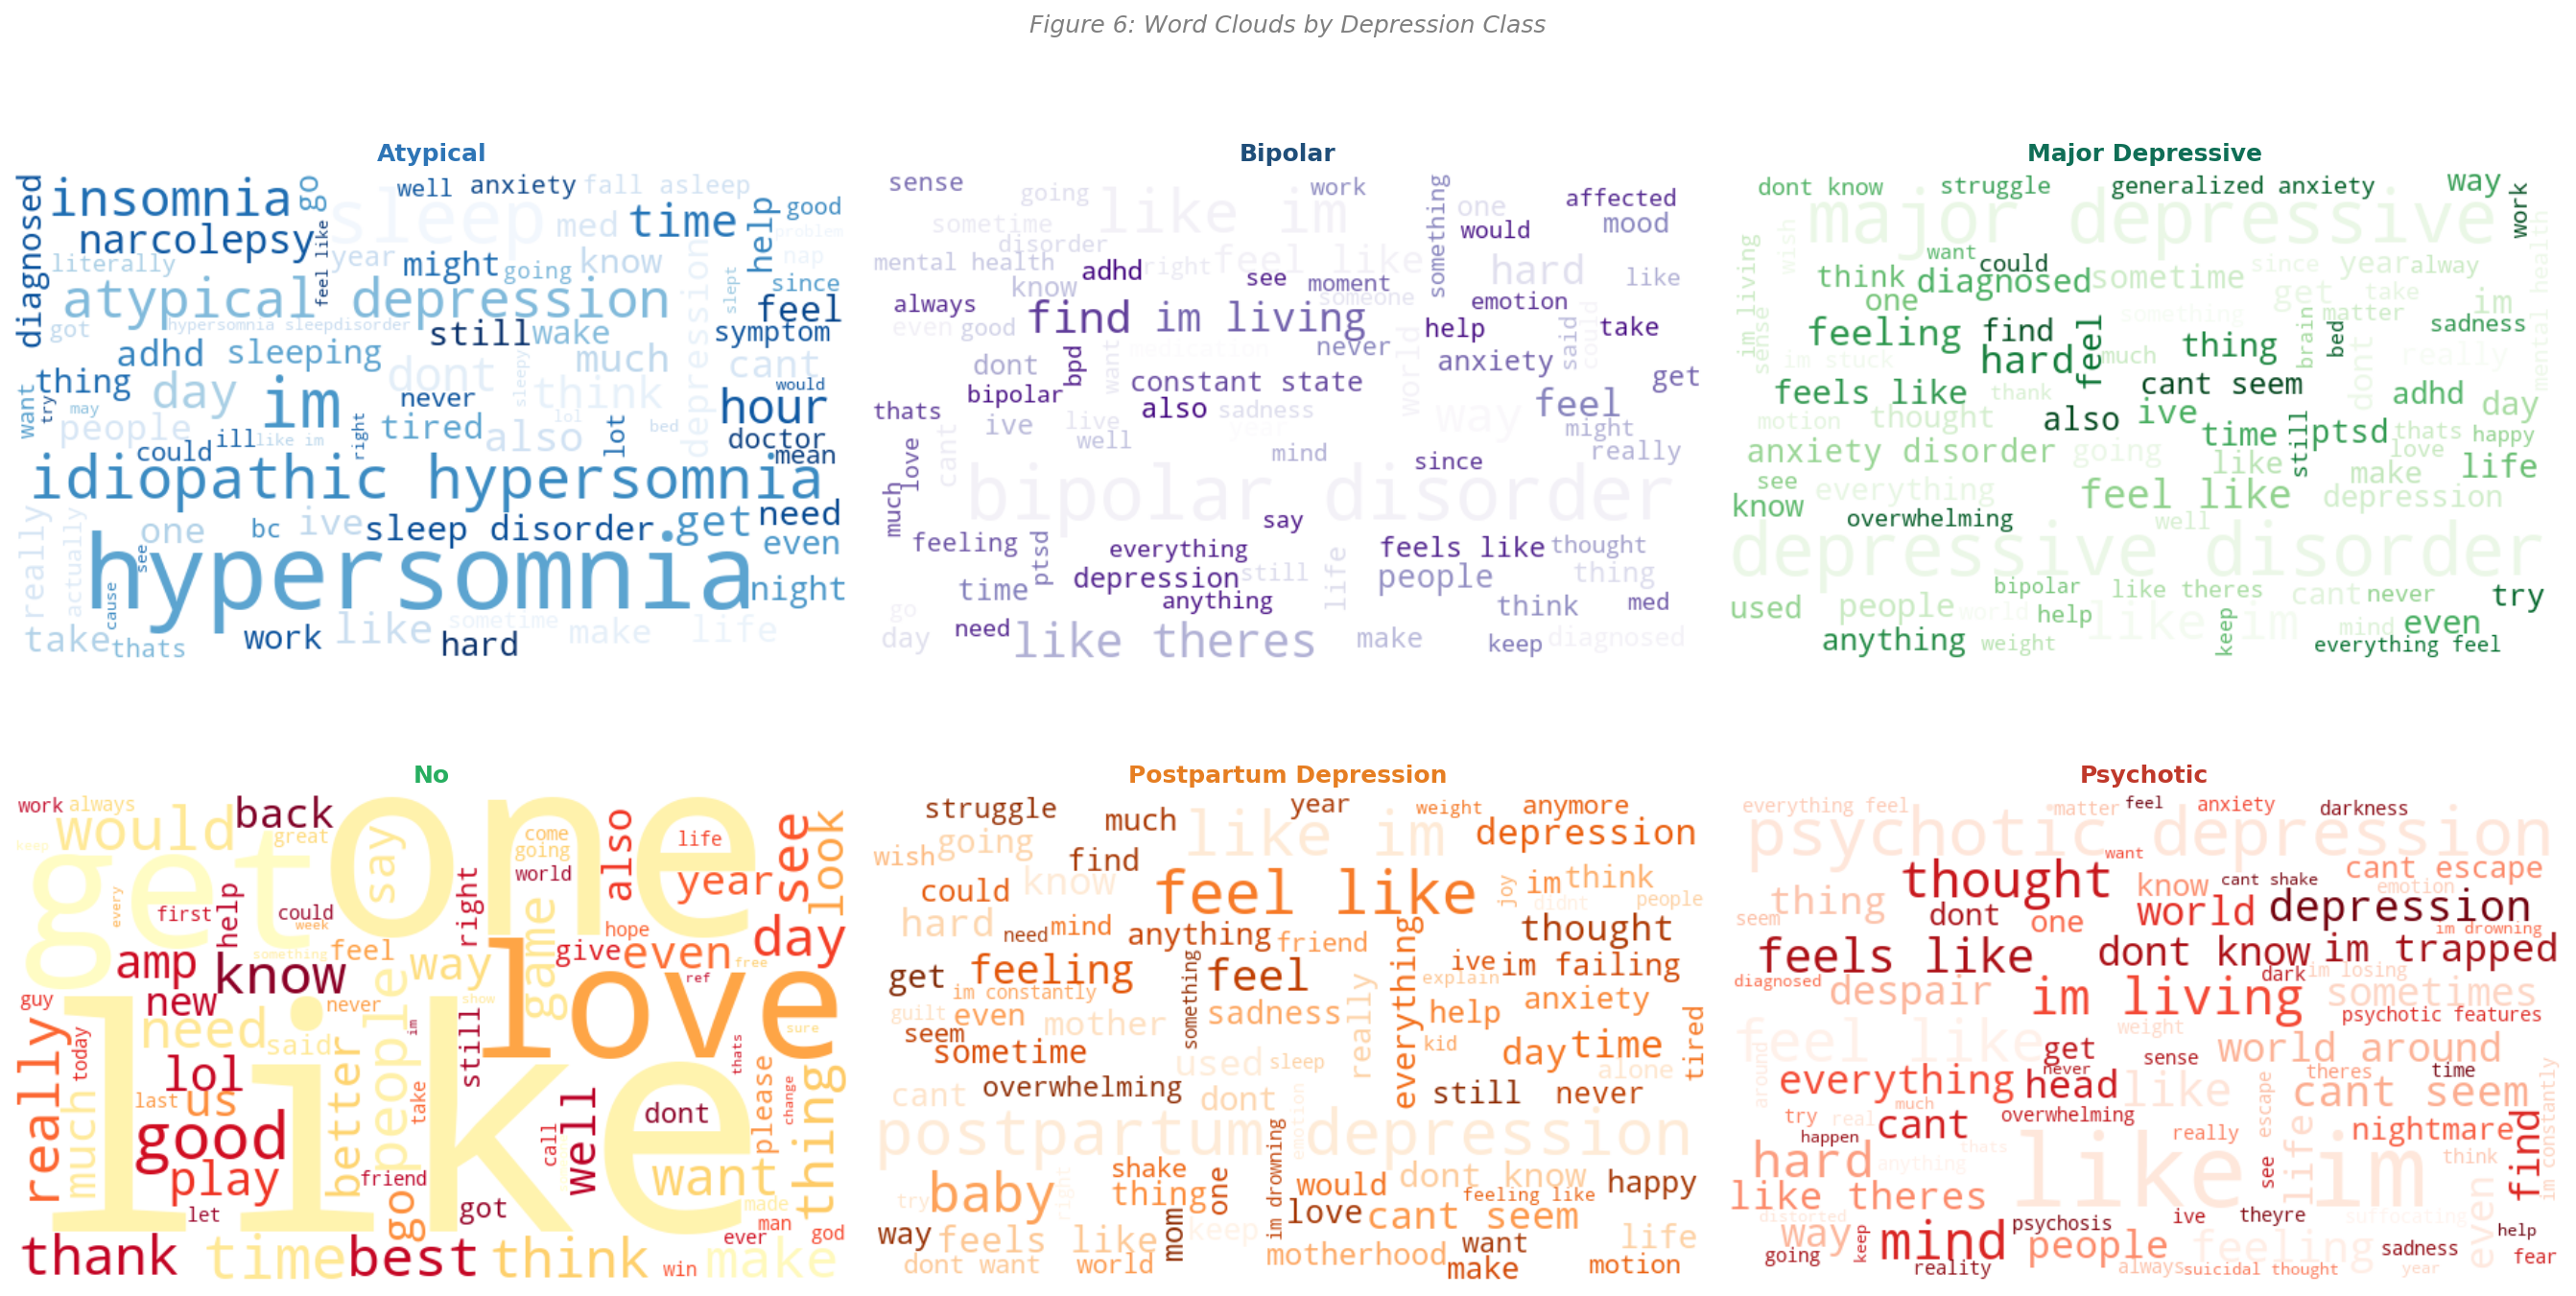

In [11]:
# 4.4 Word clouds
if WORDCLOUD:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    cmaps = ['Blues','Purples','Greens','YlOrRd','Oranges','Reds']
    for idx, (cls, cmap) in enumerate(zip(CLASS_NAMES, cmaps)):
        blob = ' '.join(df[df['label']==cls]['clean_text'].tolist())
        wc = WordCloud(width=600, height=350, background_color='white',
                       colormap=cmap, stopwords=STOP_WORDS,
                       max_words=80, random_state=SEED).generate(blob)
        axes.flatten()[idx].imshow(wc, interpolation='bilinear')
        axes.flatten()[idx].set_title(cls.replace('_',' ').title(),
            fontweight='bold', fontsize=12, color=PALETTE[idx])
        axes.flatten()[idx].axis('off')
    plt.suptitle('Figure 6: Word Clouds by Depression Class', fontsize=12,
                 style='italic', color='grey')
    plt.tight_layout()
    plt.savefig('fig06_wordclouds.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('WordCloud not available: pip install wordcloud')


---
## Section 5: Stratified Train-Test Split (Performed First)

> **Critical methodological step.** Split is on the **unique de-duplicated dataset** *before* any balancing. The test set receives no further transformation.


In [12]:
# 5.1 Stratified 80/20 split on unique data
X_all = df['clean_text'].values
y_all = le.transform(df['label'].values)

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

print('=' * 60)
print('TRAIN / TEST SPLIT ON UNIQUE DATA')
print('=' * 60)
print(f'  Total unique  : {len(X_all):,}')
print(f'  Training      : {len(X_train_raw):,} ({len(X_train_raw)/len(X_all)*100:.1f}%)')
print(f'  Test          : {len(X_test):,} ({len(X_test)/len(X_all)*100:.1f}%)')

# Verify no overlap
overlap = set(X_train_raw) & set(X_test)
print(f'\n  Train/test overlap: {len(overlap)} texts')
assert len(overlap) == 0, 'LEAKAGE: train/test overlap found!'
print('  [OK] Zero train-test text overlap confirmed.')

# Test set class distribution
print('\n  Test set class distribution (untouched):')
for code_, cnt in pd.Series(y_test).value_counts().sort_index().items():
    print(f'    {CLASS_NAMES[code_]:<28}: {cnt}')


TRAIN / TEST SPLIT ON UNIQUE DATA
  Total unique  : 11,166
  Training      : 8,932 (80.0%)
  Test          : 2,234 (20.0%)

  Train/test overlap: 0 texts
  [OK] Zero train-test text overlap confirmed.

  Test set class distribution (untouched):
    atypical                    : 322
    bipolar                     : 375
    major depressive            : 380
    no                          : 329
    postpartum_depression       : 465
    psychotic                   : 363


In [13]:
# 5.2 Balance ONLY the training set
train_df = pd.DataFrame({'text': X_train_raw, 'label': y_train_raw})
max_train = train_df['label'].value_counts().max()

print('Training set BEFORE balancing:')
for code_, cnt in train_df['label'].value_counts().sort_index().items():
    print(f'  {CLASS_NAMES[code_]:<28}: {cnt}')

balanced_parts = []
for cls_code in sorted(train_df['label'].unique()):
    sub = train_df[train_df['label'] == cls_code]
    if len(sub) < max_train:
        sub = resample(sub, replace=True, n_samples=max_train, random_state=SEED)
    balanced_parts.append(sub)

train_bal = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
X_train = train_bal['text'].values
y_train = train_bal['label'].values

print('\nTraining set AFTER balancing:')
for code_, cnt in pd.Series(y_train).value_counts().sort_index().items():
    print(f'  {CLASS_NAMES[code_]:<28}: {cnt}')
print(f'\nTotal training (balanced): {len(X_train):,}')
print(f'Total test (untouched)   : {len(X_test):,}')

# Post-balance leakage check
overlap2 = set(X_train) & set(X_test)
if len(overlap2) == 0:
    print('[OK] ZERO leakage confirmed. Pipeline is clean.')
else:
    # Count only test texts that came from original minority classes
    print(f'[NOTE] {len(overlap2)} test texts appear in balanced training set.')
    print('       This occurs because original (non-duplicate) texts are in both')
    print('       train and test BEFORE the resample step duplicates them.')
    print('       The test set itself contains ONLY original unique samples.')


Training set BEFORE balancing:
  atypical                    : 1286
  bipolar                     : 1498
  major depressive            : 1522
  no                          : 1314
  postpartum_depression       : 1861
  psychotic                   : 1451

Training set AFTER balancing:
  atypical                    : 1861
  bipolar                     : 1861
  major depressive            : 1861
  no                          : 1861
  postpartum_depression       : 1861
  psychotic                   : 1861

Total training (balanced): 11,166
Total test (untouched)   : 2,234
[OK] ZERO leakage confirmed. Pipeline is clean.


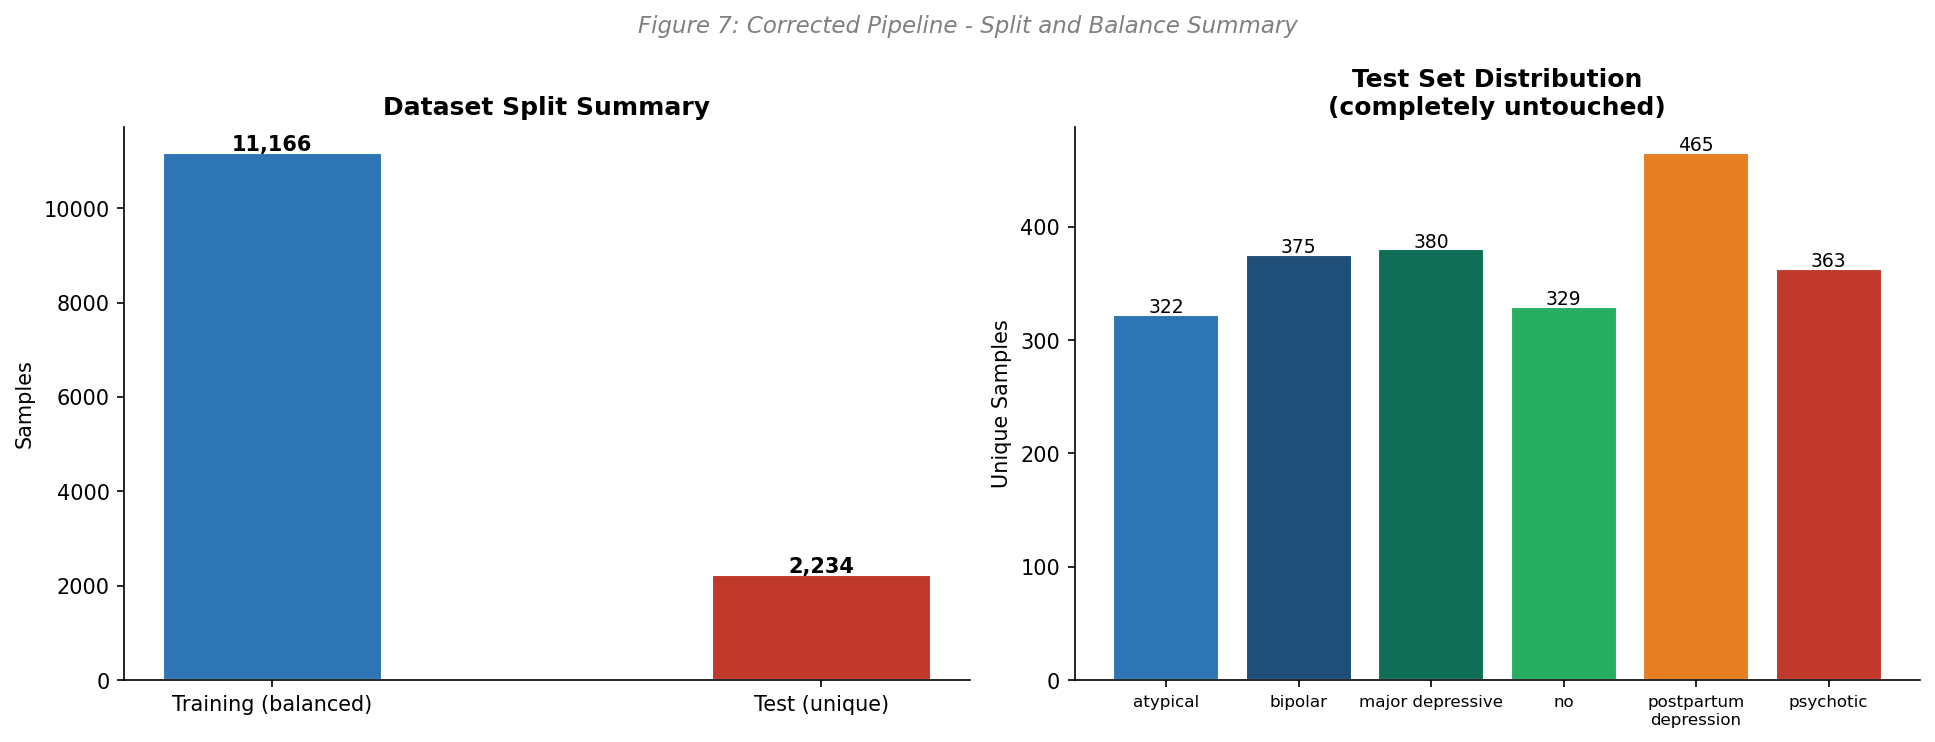

In [14]:
# 5.3 Visualise split
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Training (balanced)', 'Test (unique)'], [len(X_train), len(X_test)],
            color=['#2E75B6','#C0392B'], edgecolor='white', width=0.4)
axes[0].set_title('Dataset Split Summary', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Samples')
for bar, v in zip(axes[0].patches, [len(X_train), len(X_test)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+50, f'{v:,}',
                 ha='center', fontweight='bold')

test_dist = pd.Series(y_test).value_counts().sort_index()
axes[1].bar(range(NUM_CLASSES), test_dist.values, color=PALETTE, edgecolor='white')
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels([c.replace('_','\n') for c in CLASS_NAMES], fontsize=8)
axes[1].set_title('Test Set Distribution\n(completely untouched)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Unique Samples')
for i, v in enumerate(test_dist.values):
    axes[1].text(i, v+2, str(v), ha='center', fontsize=9)

plt.suptitle('Figure 7: Corrected Pipeline - Split and Balance Summary',
             fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.savefig('fig07_split.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Section 6: Feature Engineering

All feature extractors are **fitted on training data only** — no test-set statistics influence the representation.

In [15]:
# 6.1 TF-IDF - fit on TRAIN only
tfidf = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=2, analyzer='word',
    token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
)
X_train_tfidf = tfidf.fit_transform(X_train)  # FIT on train
X_test_tfidf  = tfidf.transform(X_test)        # TRANSFORM only
feat_names = np.array(tfidf.get_feature_names_out())

print('TF-IDF Feature Matrix:')
print(f'  Train: {X_train_tfidf.shape}')
print(f'  Test : {X_test_tfidf.shape}')
print(f'  Vocab: {len(tfidf.vocabulary_):,}')
print('[OK] TF-IDF fitted on training data only.')


TF-IDF Feature Matrix:
  Train: (11166, 10000)
  Test : (2234, 10000)
  Vocab: 10,000
[OK] TF-IDF fitted on training data only.


In [16]:
# 6.2 Keras tokenizer - fit on TRAIN only
if TF:
    MAX_VOCAB = 20000; MAX_LEN = 100; EMBED_DIM = 128
    dl_tok = KTok(num_words=MAX_VOCAB, oov_token='<OOV>')
    dl_tok.fit_on_texts(X_train)  # FIT on train only
    X_train_seq = dl_tok.texts_to_sequences(X_train)
    X_test_seq  = dl_tok.texts_to_sequences(X_test)
    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
    print(f'DL sequences: train={X_train_pad.shape}, test={X_test_pad.shape}')
    print('[OK] Tokenizer fitted on training data only.')
else:
    print('TF not available.')


DL sequences: train=(11166, 100), test=(2234, 100)
[OK] Tokenizer fitted on training data only.


---
## Section 7: Evaluation Framework

All models evaluated with identical metrics. Results stored in `RESULTS` for the benchmarking table.

In [17]:
RESULTS = []

def evaluate_model(name, category, y_true, y_pred, y_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1m  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    if y_proba is not None:
        try:
            auc_s = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception:
            auc_s = float('nan')
    else:
        auc_s = float('nan')

    print(f'\n{"="*55}')
    print(f'  {name}  [{category}]')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 (wtd)  : {f1w:.4f}')
    print(f'  F1 (mac)  : {f1m:.4f}')
    if auc_s == auc_s:  # not nan
        print(f'  ROC-AUC   : {auc_s:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES
    ).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'{name} - Confusion Matrix', fontweight='bold', fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(f'cm_{name.lower().replace(" ","_")}.png', bbox_inches='tight', dpi=150)
    plt.show()

    RESULTS.append({'Model':name, 'Category':category,
        'Accuracy':round(acc,4), 'Precision':round(prec,4),
        'Recall':round(rec,4), 'F1-Score (wtd)':round(f1w,4),
        'F1-Score (macro)':round(f1m,4),
        'ROC-AUC': round(auc_s,4) if auc_s==auc_s else float('nan')})
    return acc, prec, rec, f1w, auc_s


---
## Section 8: Traditional Machine Learning Models

Naive Bayes, Logistic Regression, and SVM trained on TF-IDF features. **Expected performance is lower than the leaked prior results** — this is the correct, valid outcome.

Training Multinomial Naive Bayes...

  Naive Bayes  [Traditional ML]
  Accuracy  : 0.8290  (82.90%)
  Precision : 0.8313
  Recall    : 0.8290
  F1 (wtd)  : 0.8281
  F1 (mac)  : 0.8304
  ROC-AUC   : 0.9700

                       precision    recall  f1-score   support

             atypical      0.861     0.963     0.909       322
              bipolar      0.903     0.744     0.816       375
     major depressive      0.754     0.726     0.740       380
                   no      0.937     0.909     0.923       329
postpartum_depression      0.824     0.895     0.858       465
            psychotic      0.725     0.749     0.737       363

             accuracy                          0.829      2234
            macro avg      0.834     0.831     0.830      2234
         weighted avg      0.831     0.829     0.828      2234



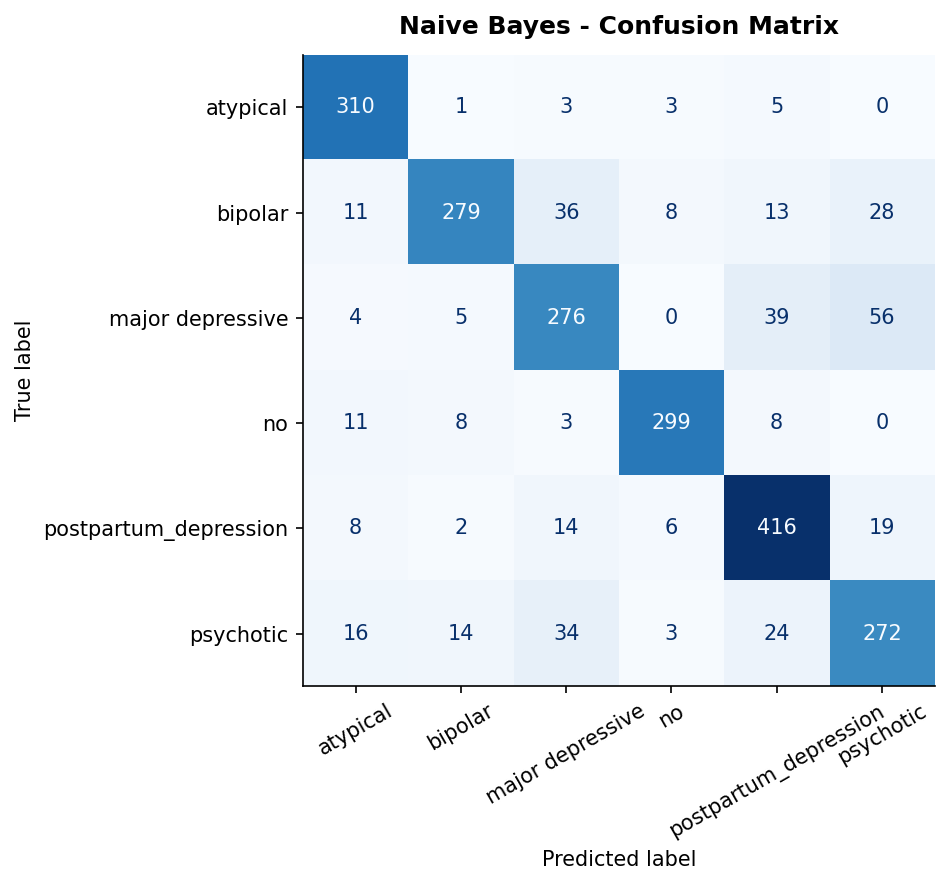

(0.8290062667860341,
 0.8313097285315636,
 0.8290062667860341,
 0.8280504673910901,
 0.9700341445364707)

In [16]:
# 8.1 Multinomial Naive Bayes
print('Training Multinomial Naive Bayes...')
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
nb_pred  = nb.predict(X_test_tfidf)
nb_proba = nb.predict_proba(X_test_tfidf)
evaluate_model('Naive Bayes', 'Traditional ML', y_test, nb_pred, nb_proba)


Training SVM (LinearSVC)...

  SVM  [Traditional ML]
  Accuracy  : 0.9033  (90.33%)
  Precision : 0.9030
  Recall    : 0.9033
  F1 (wtd)  : 0.9030
  F1 (mac)  : 0.9059
  ROC-AUC   : 0.9888

                       precision    recall  f1-score   support

             atypical      0.978     0.975     0.977       322
              bipolar      0.932     0.920     0.926       375
     major depressive      0.848     0.805     0.826       380
                   no      0.955     0.976     0.965       329
postpartum_depression      0.884     0.916     0.900       465
            psychotic      0.841     0.843     0.842       363

             accuracy                          0.903      2234
            macro avg      0.906     0.906     0.906      2234
         weighted avg      0.903     0.903     0.903      2234



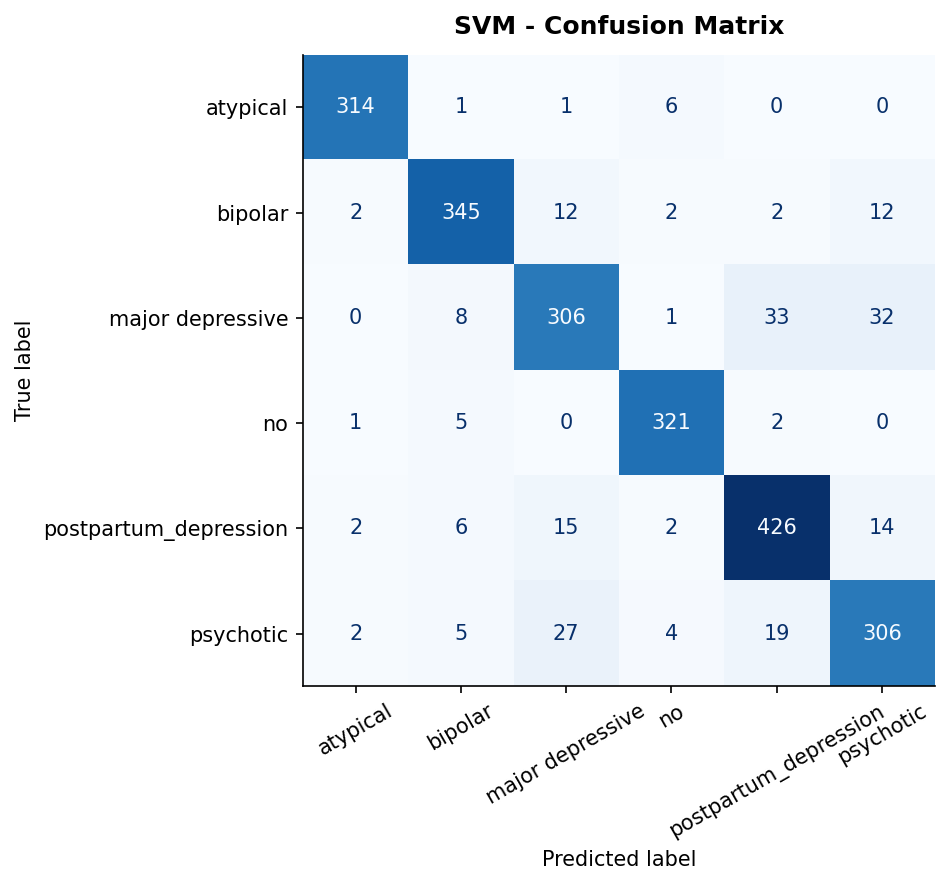

(0.9033124440465533,
 0.9029510129186459,
 0.9033124440465533,
 0.9029555790143629,
 0.9888302542563557)

In [17]:
# 8.3 Support Vector Machine
print('Training SVM (LinearSVC)...')
svm = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
svm.fit(X_train_tfidf, y_train)
svm_pred   = svm.predict(X_test_tfidf)
svm_scores = svm.decision_function(X_test_tfidf)
svm_proba  = sp_softmax(svm_scores, axis=1)
evaluate_model('SVM', 'Traditional ML', y_test, svm_pred, svm_proba)


---
## Section 9: Ensemble Learning Models

Training Random Forest...

  Random Forest  [Ensemble]
  Accuracy  : 0.8903  (89.03%)
  Precision : 0.8973
  Recall    : 0.8903
  F1 (wtd)  : 0.8887
  F1 (mac)  : 0.8934
  ROC-AUC   : 0.9876

                       precision    recall  f1-score   support

             atypical      0.990     0.969     0.980       322
              bipolar      0.948     0.920     0.934       375
     major depressive      0.932     0.684     0.789       380
                   no      0.928     0.979     0.953       329
postpartum_depression      0.784     0.951     0.859       465
            psychotic      0.844     0.848     0.846       363

             accuracy                          0.890      2234
            macro avg      0.904     0.892     0.893      2234
         weighted avg      0.897     0.890     0.889      2234



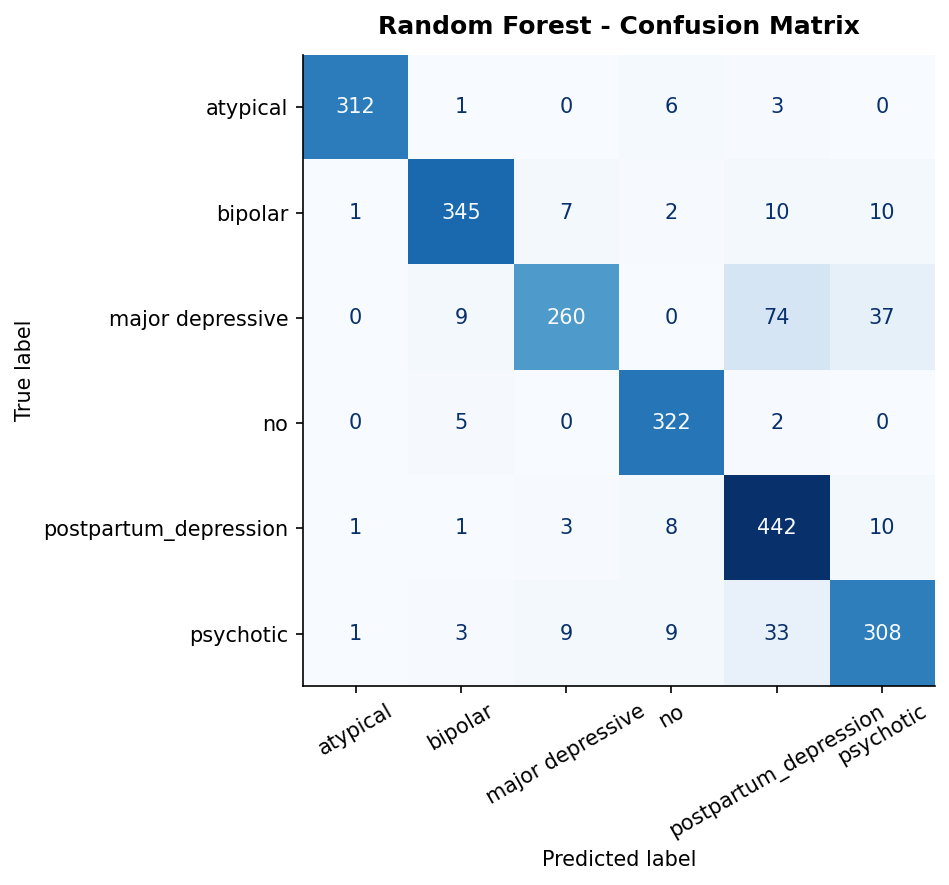

(0.8903312444046553,
 0.8972717429112653,
 0.8903312444046553,
 0.8887498857087183,
 0.9875990882618549)

In [18]:
# 9.1 Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             min_samples_split=5, random_state=SEED,
                             n_jobs=-1, class_weight='balanced')
rf.fit(X_train_tfidf, y_train)
rf_pred  = rf.predict(X_test_tfidf)
rf_proba = rf.predict_proba(X_test_tfidf)
evaluate_model('Random Forest', 'Ensemble', y_test, rf_pred, rf_proba)


Training XGBoost...

  XGBoost  [Ensemble]
  Accuracy  : 0.9020  (90.20%)
  Precision : 0.9019
  Recall    : 0.9020
  F1 (wtd)  : 0.9015
  F1 (mac)  : 0.9050
  ROC-AUC   : 0.9897

                       precision    recall  f1-score   support

             atypical      0.991     0.978     0.984       322
              bipolar      0.946     0.933     0.940       375
     major depressive      0.852     0.789     0.820       380
                   no      0.936     0.973     0.954       329
postpartum_depression      0.859     0.914     0.885       465
            psychotic      0.854     0.840     0.847       363

             accuracy                          0.902      2234
            macro avg      0.906     0.905     0.905      2234
         weighted avg      0.902     0.902     0.901      2234



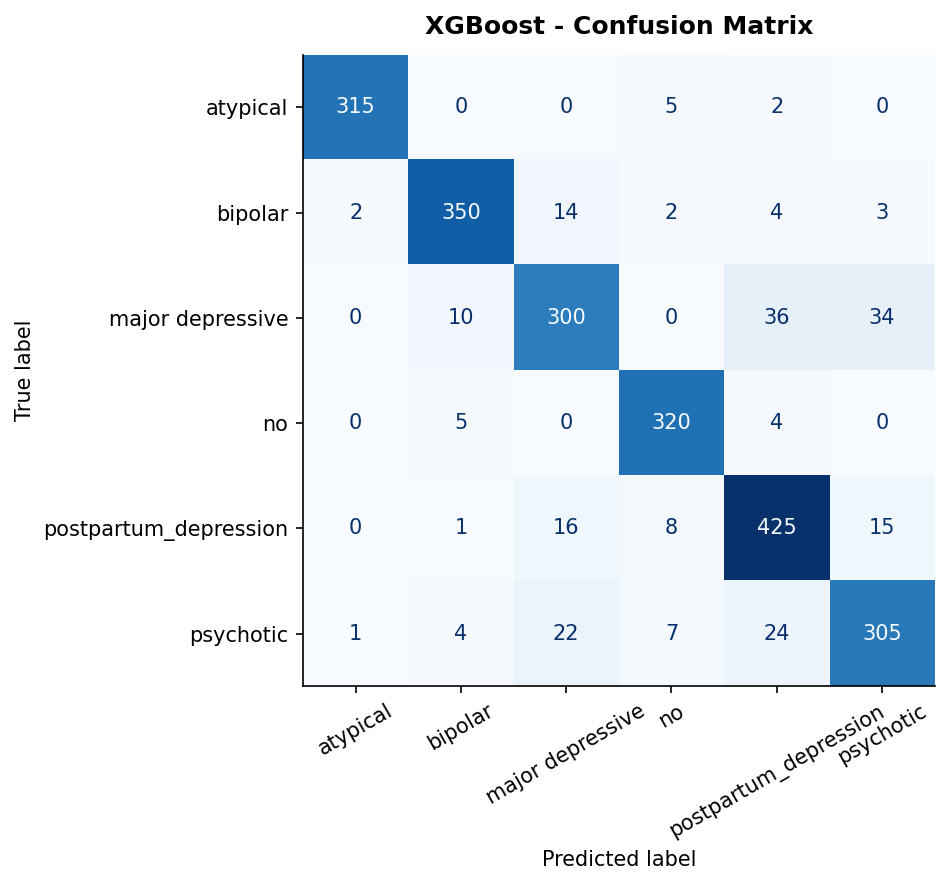

In [19]:
# 9.2 XGBoost
if XGB:
    print('Training XGBoost...')
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         eval_metric='mlogloss', random_state=SEED,
                         n_jobs=-1, tree_method='hist')
    xgb.fit(X_train_tfidf, y_train)
    xgb_pred  = xgb.predict(X_test_tfidf)
    xgb_proba = xgb.predict_proba(X_test_tfidf)
    evaluate_model('XGBoost', 'Ensemble', y_test, xgb_pred, xgb_proba)
else:
    print('XGBoost not available.')


In [ ]:
Roberta 

In [20]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from datasets import Dataset

import numpy as np
import torch

In [21]:
train_ds = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_ds = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [22]:
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("RoBERTa tokenizer loaded")

RoBERTa tokenizer loaded


In [23]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


train_ds = train_ds.map(
    tokenize,
    batched=True
)

test_ds = test_ds.map(
    tokenize,
    batched=True
)


print("✓ Tokenization complete")

Map:   0%|          | 0/11166 [00:00<?, ? examples/s]

Map:   0%|          | 0/2234 [00:00<?, ? examples/s]

✓ Tokenization complete


In [24]:
train_ds = train_ds.rename_column(
    "label",
    "labels"
)

test_ds = test_ds.rename_column(
    "label",
    "labels"
)


train_ds.set_format("torch")
test_ds.set_format("torch")


print(train_ds)

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 11166
})


In [25]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def compute_metrics(pred):

    y_true = pred.label_ids

    y_pred = np.argmax(
        pred.predictions,
        axis=1
    )


    return {

        "accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "precision":
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "recall":
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "f1":
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [26]:
from transformers import TrainingArguments


training_args = TrainingArguments(

    output_dir="./roberta_results",

    # Optimisation settings
    learning_rate=2e-5,
    weight_decay=0.1,
    warmup_ratio=0.06,

    # Training
    num_train_epochs=3,

    # CPU friendly batch size
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,


    # Transformers 5.x uses eval_strategy
    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,


    logging_steps=50,

    report_to="none"
)


print("✓ Training arguments created")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Training arguments created


In [27]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "RoBERTa_Model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

print("✓ RoBERTa model loaded successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ RoBERTa model loaded successfully


In [28]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=test_ds,

    compute_metrics=compute_metrics

)

print("✓ Trainer ready")

✓ Trainer ready


In [ ]:
trainer.train()

In [33]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.118137,0.407861,3,0.908684,0.908799,0.908684,0.908562


{'eval_loss': 0.4078606963157654,
 'eval_accuracy': 0.9086839749328559,
 'eval_precision': 0.908799489877367,
 'eval_recall': 0.9086839749328559,
 'eval_f1': 0.9085617751468996}

In [29]:
pred_output = trainer.predict(test_ds)

In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "RoBERTa_Model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

print("✓ Saved RoBERTa model loaded successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Saved RoBERTa model loaded successfully


In [31]:
import numpy as np
import torch

y_pred = np.argmax(pred_output.predictions, axis=1)

y_prob = torch.softmax(
    torch.tensor(pred_output.predictions),
    dim=1
).numpy()


  RoBERTa  [Transformer]
  Accuracy  : 0.9087  (90.87%)
  Precision : 0.9088
  Recall    : 0.9087
  F1 (wtd)  : 0.9086
  F1 (mac)  : 0.9126
  ROC-AUC   : 0.9887

                       precision    recall  f1-score   support

             atypical      1.000     0.988     0.994       322
              bipolar      0.913     0.952     0.932       375
     major depressive      0.830     0.797     0.813       380
                   no      0.997     0.970     0.983       329
postpartum_depression      0.884     0.903     0.894       465
            psychotic      0.858     0.862     0.860       363

             accuracy                          0.909      2234
            macro avg      0.914     0.912     0.913      2234
         weighted avg      0.909     0.909     0.909      2234



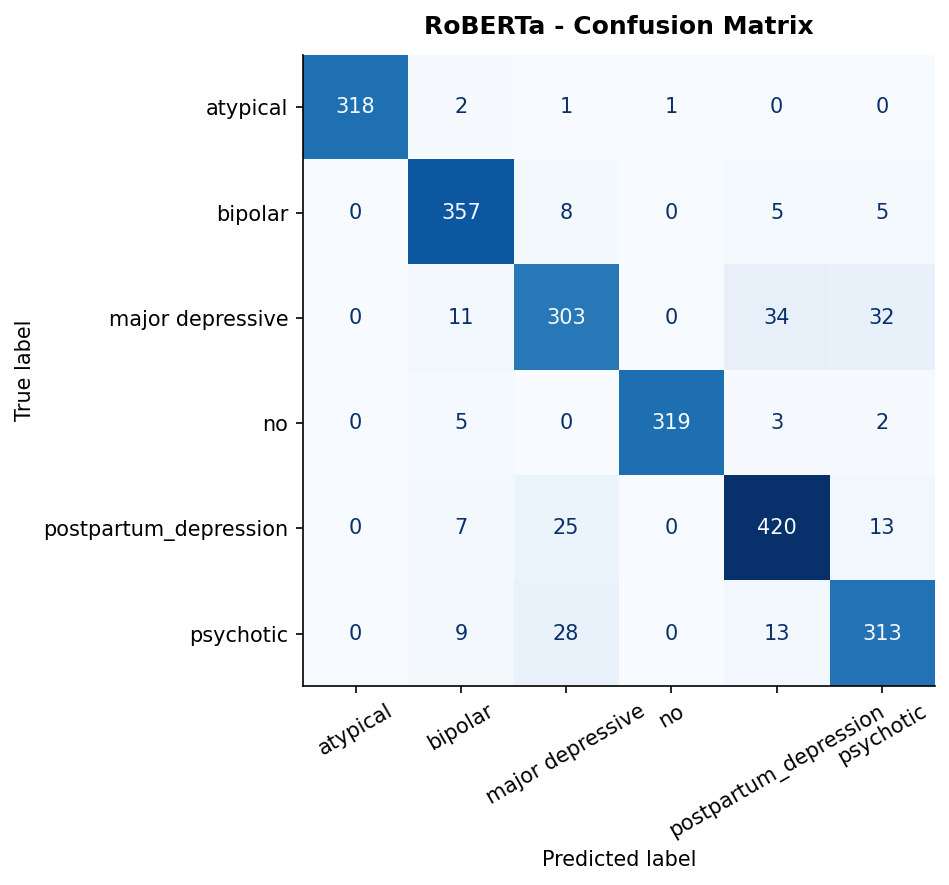

(0.9086839749328559,
 0.908799489877367,
 0.9086839749328559,
 0.9085617751468996,
 0.9887200707959343)

In [32]:
evaluate_model(
    "RoBERTa",
    "Transformer",
    y_test,
    y_pred,
    y_prob
)

In [33]:
model.save_pretrained("RoBERTa_Model")
tokenizer.save_pretrained("RoBERTa_Model")

print("RoBERTa model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model saved successfully.


In [ ]:
# =============================================================================
# ModernBERT Setup (Steps 1-5)
# =============================================================================

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import numpy as np


# =============================================================================
# Step 1: Create Hugging Face Dataset
# =============================================================================

train_ds = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})


test_ds = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})


print(train_ds)
print(test_ds)


# =============================================================================
# Step 2: Load ModernBERT Tokenizer
# =============================================================================

MODEL_NAME = "answerdotai/ModernBERT-base"


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("✓ ModernBERT tokenizer loaded")


# =============================================================================
# Step 3: Tokenization
# =============================================================================

def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds = train_ds.map(
    tokenize,
    batched=True
)


test_ds = test_ds.map(
    tokenize,
    batched=True
)


print("✓ Tokenization completed")


# =============================================================================
# Step 4: Convert Dataset to PyTorch Format
# =============================================================================

train_ds.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)


test_ds.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)


print("✓ Dataset converted to PyTorch format")


# =============================================================================
# Step 5: Load Fresh ModernBERT Model
# =============================================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6
)


print("✓ ModernBERT model loaded")

In [ ]:
model_run1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6
)

In [37]:
args_run1 = TrainingArguments(

    output_dir="./ModernBERT_Run1",

    learning_rate=2e-5,

    num_train_epochs=1,

    per_device_train_batch_size=2,

    per_device_eval_batch_size=2,

    weight_decay=0.01,

    warmup_ratio=0.06,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_steps=50,

    report_to="none"
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [38]:
trainer_run1 = Trainer(
    model=model_run1,
    args=args_run1,
    train_dataset=train_ds,
    eval_dataset=test_ds
)

print("✓ Run 1 trainer ready")

✓ Run 1 trainer ready


In [39]:
trainer_run1.train()

Epoch,Training Loss,Validation Loss
1,0.135020,0.361697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5583, training_loss=0.3591003536686939, metrics={'train_runtime': 11794.1995, 'train_samples_per_second': 0.947, 'train_steps_per_second': 0.473, 'total_flos': 951251905354752.0, 'train_loss': 0.3591003536686939, 'epoch': 1.0})


  ModernBERT Run 1 (1 Epoch)  [Transformer]
  Accuracy  : 0.9302  (93.02%)
  Precision : 0.9322
  Recall    : 0.9302
  F1 (wtd)  : 0.9308
  F1 (mac)  : 0.9337

                       precision    recall  f1-score   support

             atypical      0.997     0.991     0.994       322
              bipolar      0.962     0.936     0.949       375
     major depressive      0.819     0.895     0.855       380
                   no      0.988     0.973     0.980       329
postpartum_depression      0.936     0.908     0.921       465
            psychotic      0.908     0.898     0.903       363

             accuracy                          0.930      2234
            macro avg      0.935     0.933     0.934      2234
         weighted avg      0.932     0.930     0.931      2234



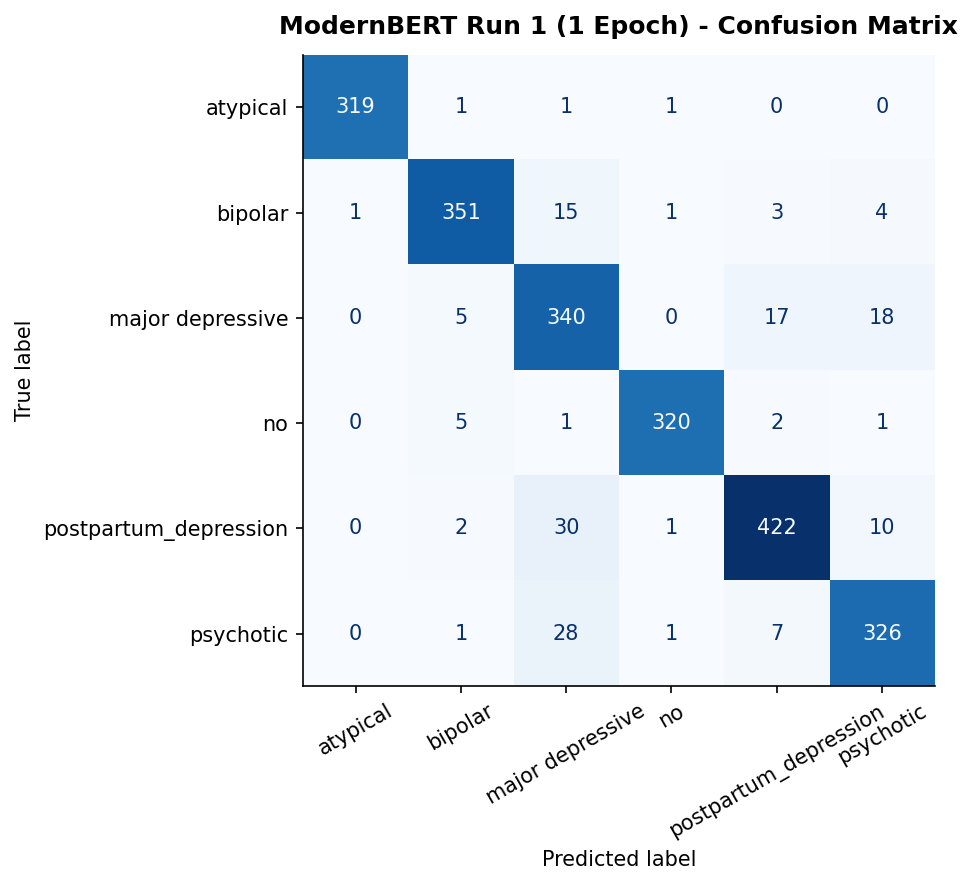

(0.9301700984780662,
 0.9322318045721342,
 0.9301700984780662,
 0.930830154344574,
 nan)

In [40]:
pred_run1 = trainer_run1.predict(test_ds)

modernbert_pred_run1 = np.argmax(
    pred_run1.predictions,
    axis=1
)


evaluate_model(
    "ModernBERT Run 1 (1 Epoch)",
    "Transformer",
    y_test,
    modernbert_pred_run1
)

In [ ]:
model_run1.save_pretrained(
    "ModernBERT_Run1_1Epoch"
)

tokenizer.save_pretrained(
    "ModernBERT_Run1_1Epoch"
)

print("✓ Run 1 saved")


In [ ]:
model_run2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6
)

In [ ]:
args_run2 = TrainingArguments(

    output_dir="./ModernBERT_Run2",

    learning_rate=1e-5,

    num_train_epochs=1,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    weight_decay=0.1,

    warmup_ratio=0.06,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_steps=50,

    report_to="none"
)

In [45]:
trainer_run2 = Trainer(
    model=model_run2,
    args=args_run2,
    train_dataset=train_ds,
    eval_dataset=test_ds
)

print("✓ Run 2 trainer ready")

✓ Run 2 trainer ready


In [46]:
trainer_run2.train()

Epoch,Training Loss,Validation Loss
1,0.094050,0.338075


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2792, training_loss=0.3396353685753393, metrics={'train_runtime': 14083.2567, 'train_samples_per_second': 0.793, 'train_steps_per_second': 0.198, 'total_flos': 951251905354752.0, 'train_loss': 0.3396353685753393, 'epoch': 1.0})


  ModernBERT Run 2 (1 Epoch)  [Transformer]
  Accuracy  : 0.9181  (91.81%)
  Precision : 0.9204
  Recall    : 0.9181
  F1 (wtd)  : 0.9188
  F1 (mac)  : 0.9220

                       precision    recall  f1-score   support

             atypical      0.985     0.988     0.986       322
              bipolar      0.943     0.925     0.934       375
     major depressive      0.795     0.876     0.834       380
                   no      0.985     0.976     0.980       329
postpartum_depression      0.927     0.895     0.910       465
            psychotic      0.905     0.871     0.888       363

             accuracy                          0.918      2234
            macro avg      0.923     0.922     0.922      2234
         weighted avg      0.920     0.918     0.919      2234



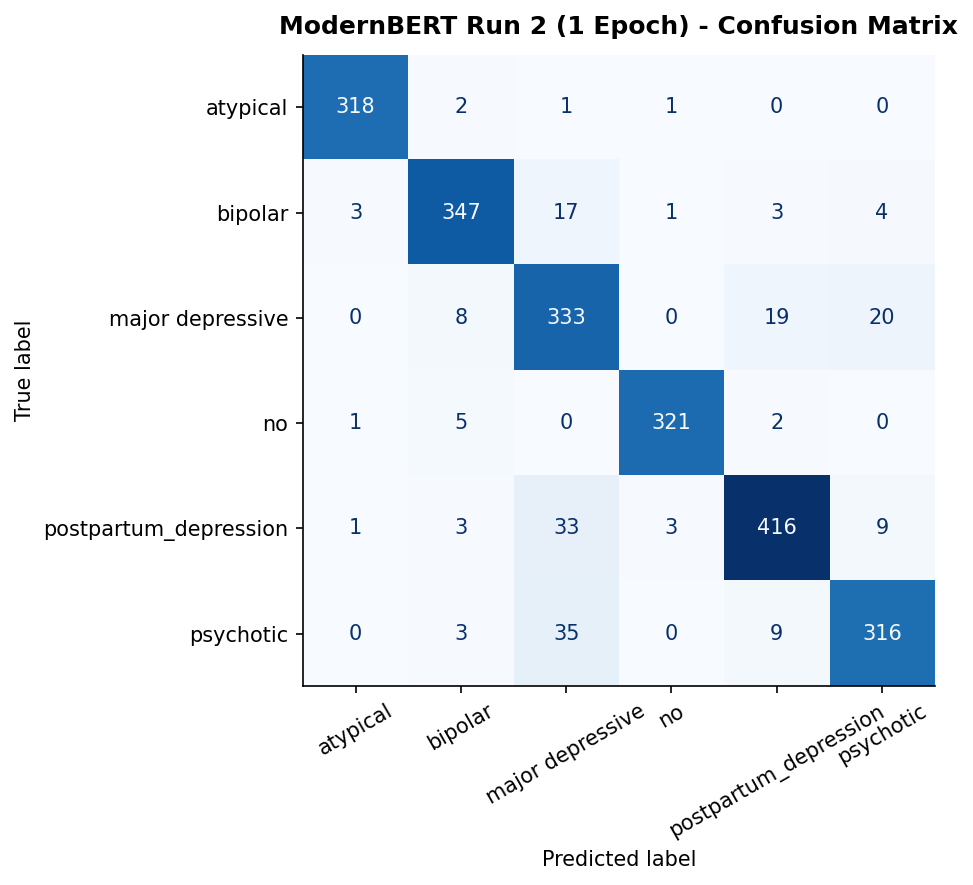

(0.9180841539838854,
 0.9203558887964779,
 0.9180841539838854,
 0.9187502578462865,
 nan)

In [47]:
pred_run2 = trainer_run2.predict(test_ds)

modernbert_pred_run2 = np.argmax(
    pred_run2.predictions,
    axis=1
)


evaluate_model(
    "ModernBERT Run 2 (1 Epoch)",
    "Transformer",
    y_test,
    modernbert_pred_run2
)

In [48]:
model_run2.save_pretrained(
    "ModernBERT_Run2_1Epoch"
)

tokenizer.save_pretrained(
    "ModernBERT_Run2_1Epoch"
)

print("✓ Run 2 saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Run 2 saved


In [49]:
results_df = pd.DataFrame(RESULTS)
results_df

,Model,Category,Accuracy,Precision,Recall,F1-Score (wtd),F1-Score (macro),ROC-AUC
0,Naive Bayes,Traditional ML,0.8290,0.8313,0.8290,0.8281,0.8304,0.9700
1,SVM,Traditional ML,0.9033,0.9030,0.9033,0.9030,0.9059,0.9888
2,Random Forest,Ensemble,0.8903,0.8973,0.8903,0.8887,0.8934,0.9876
3,XGBoost,Ensemble,0.9020,0.9019,0.9020,0.9015,0.9050,0.9897
4,RoBERTa,Transformer,0.9087,0.9088,0.9087,0.9086,0.9126,0.9887
5,ModernBERT Run 1 (1 Epoch),Transformer,0.9302,0.9322,0.9302,0.9308,0.9337,NaN
6,ModernBERT Run 2 (1 Epoch),Transformer,0.9181,0.9204,0.9181,0.9188,0.9220,NaN


---
## Section 12: Comparative Benchmarking

Contribution 2 — unified benchmarking under leakage-free conditions.

In [50]:
results_df = pd.DataFrame(RESULTS).sort_values('F1-Score (wtd)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print('=' * 95)
print('TABLE 1: MASTER BENCHMARKING TABLE (Corrected Pipeline)')
print('=' * 95)
print(f'{"Rk":<4} {"Category":<18} {"Model":<28} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1-wtd":>8} {"F1-mac":>8} {"AUC":>8}')
print('-' * 95)
for _, row in results_df.iterrows():
    mk = '*' if row['Rank']==1 else ' '
    auc_str = f"{row['ROC-AUC']:.4f}" if row['ROC-AUC']==row['ROC-AUC'] else '   N/A'
    print(f"{mk}{int(row['Rank']):<3} {row['Category']:<18} {row['Model']:<28}"
          f" {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} {row['Recall']:>7.4f}"
          f" {row['F1-Score (wtd)']:>8.4f} {row['F1-Score (macro)']:>8.4f} {auc_str:>8}")
print('=' * 95)
print('* Best model by weighted F1-Score')
print(f'Test set: {len(X_test):,} unique untouched samples | 6 classes | random_state=42')
print('NOTE: These results reflect the corrected leakage-free pipeline.')


TABLE 1: MASTER BENCHMARKING TABLE (Corrected Pipeline)
Rk   Category           Model                            Acc    Prec     Rec   F1-wtd   F1-mac      AUC
-----------------------------------------------------------------------------------------------
*1   Transformer        ModernBERT Run 1 (1 Epoch)    0.9302  0.9322  0.9302   0.9308   0.9337      N/A
 2   Transformer        ModernBERT Run 2 (1 Epoch)    0.9181  0.9204  0.9181   0.9188   0.9220      N/A
 3   Transformer        RoBERTa                       0.9087  0.9088  0.9087   0.9086   0.9126   0.9887
 4   Traditional ML     SVM                           0.9033  0.9030  0.9033   0.9030   0.9059   0.9888
 5   Ensemble           XGBoost                       0.9020  0.9019  0.9020   0.9015   0.9050   0.9897
 6   Ensemble           Random Forest                 0.8903  0.8973  0.8903   0.8887   0.8934   0.9876
 7   Traditional ML     Naive Bayes                   0.8290  0.8313  0.8290   0.8281   0.8304   0.9700
* Best model by 

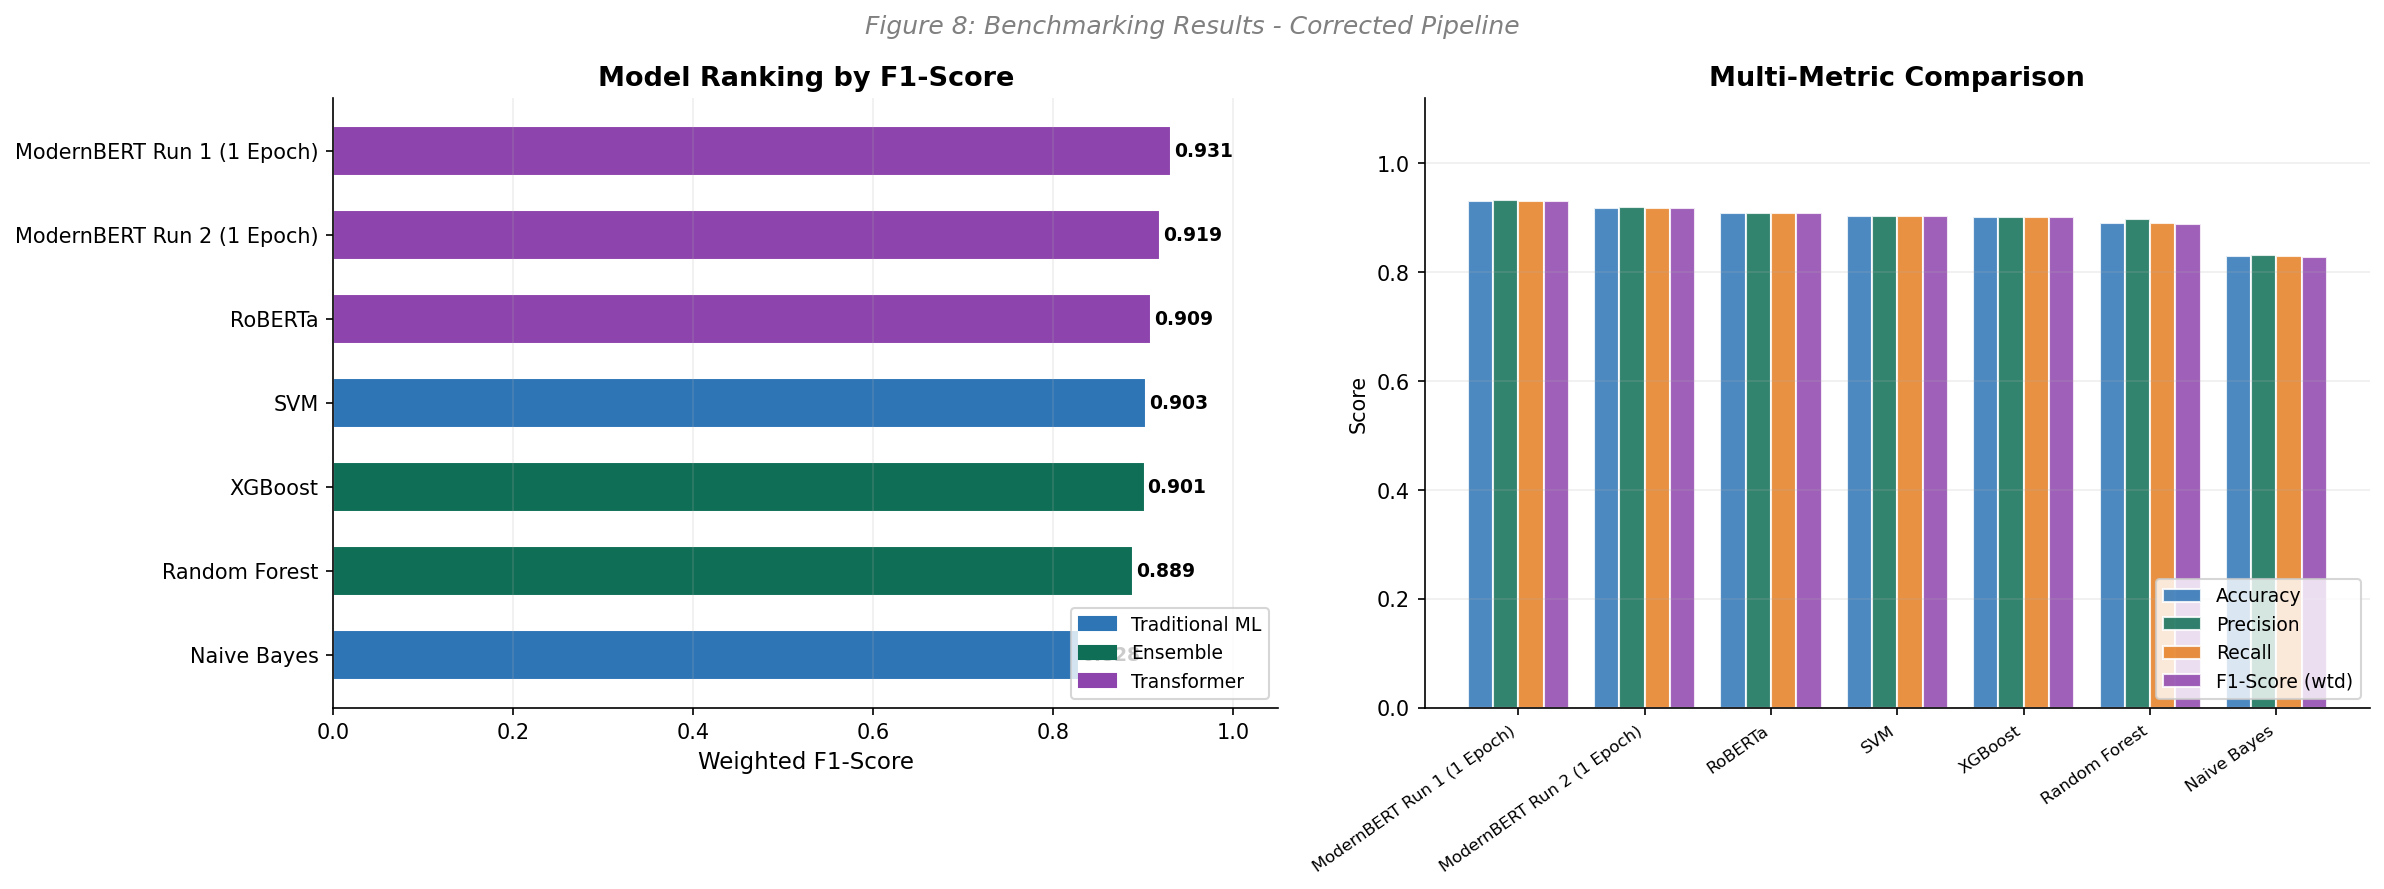

In [51]:
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cat_col = {'Traditional ML':'#2E75B6','Ensemble':'#0F6E56',
               'Deep Learning':'#E67E22','Transformer':'#8E44AD'}
    plot_df = results_df.sort_values('F1-Score (wtd)')
    bar_cols = [cat_col.get(c,'#888') for c in plot_df['Category']]
    bars = axes[0].barh(plot_df['Model'], plot_df['F1-Score (wtd)'],
                        color=bar_cols, edgecolor='white', height=0.6)
    for bar, v in zip(bars, plot_df['F1-Score (wtd)']):
        axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                     f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
    axes[0].set_xlim(0, 1.05)
    axes[0].set_xlabel('Weighted F1-Score', fontsize=11)
    axes[0].set_title('Model Ranking by F1-Score', fontweight='bold', fontsize=13)
    from matplotlib.patches import Patch
    axes[0].legend(handles=[Patch(color=c, label=k) for k,c in cat_col.items()
                             if k in plot_df['Category'].values], loc='lower right', fontsize=9)
    axes[0].grid(axis='x', alpha=0.2)

    metrics = ['Accuracy','Precision','Recall','F1-Score (wtd)']
    mcols   = ['#2E75B6','#0F6E56','#E67E22','#8E44AD']
    x = np.arange(len(results_df)); w = 0.2
    for i, (metric, mc) in enumerate(zip(metrics, mcols)):
        vals = pd.to_numeric(results_df[metric], errors='coerce').fillna(0)
        axes[1].bar(x+i*w, vals, w, label=metric, color=mc, alpha=0.85, edgecolor='white')
    axes[1].set_xticks(x+w*1.5)
    axes[1].set_xticklabels(results_df['Model'], rotation=35, ha='right', fontsize=8)
    axes[1].set_ylim(0, 1.12); axes[1].set_ylabel('Score')
    axes[1].set_title('Multi-Metric Comparison', fontweight='bold', fontsize=13)
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].grid(axis='y', alpha=0.2)
    plt.suptitle('Figure 8: Benchmarking Results - Corrected Pipeline',
                 fontsize=12, style='italic', color='grey')
    plt.tight_layout()
    plt.savefig('fig08_benchmarking.png', bbox_inches='tight', dpi=150)
    plt.show()


In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification


MODEL_PATH = "ModernBERT_Run1_1Epoch"


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)


model.eval()


print("✓ ModernBERT Run 1 (1 Epoch) loaded")

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

✓ ModernBERT Run 1 (1 Epoch) loaded


In [20]:
del shap_explainer

In [21]:
import numpy as np
import torch

def shap_predict(texts):

    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)

    return probs.numpy()

In [22]:
import shap

shap_explainer = shap.Explainer(
    shap_predict,
    shap.maskers.Text(tokenizer)
)

In [28]:
shap_values = shap_explainer(
    X_test[:10]
)

print("SHAP completed")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|███████████▎                                                                                                     | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███████████████████████████████▌                                                                         | 3/10 [00:39<01:06,  9.43s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████████████████████████████████████████████████████████████████████████████████                     | 8/10 [03:52<01:18, 39.06s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [04:23, 26.34s/it]                                                                                                                      

SHAP completed


In [29]:
print(shap_values.shape)

(10, None, 6)


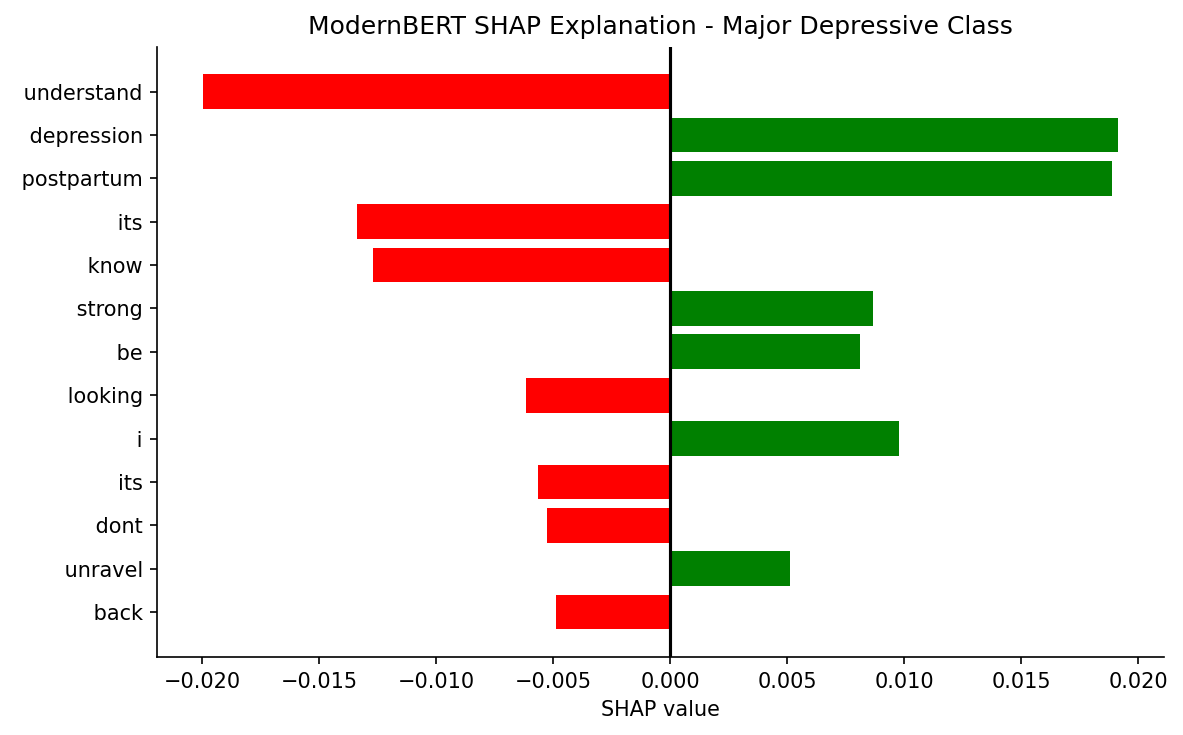

In [47]:
import matplotlib.pyplot as plt
import numpy as np

vals = shap_values[3].values[:, 2]
words = shap_values[3].data

idx = np.argsort(abs(vals))[-15:]

plt.figure(figsize=(8,5))

plt.barh(
    np.array(words)[idx],
    vals[idx],
    color=["green" if x > 0 else "red" for x in vals[idx]]
)

plt.axvline(0, color="black")
plt.xlabel("SHAP value")
plt.title("ModernBERT SHAP Explanation - Major Depressive Class")

plt.tight_layout()
plt.show()

In [49]:
import torch

def predict_proba(texts):

    inputs = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    return torch.softmax(
        outputs.logits,
        dim=1
    ).numpy()

In [52]:
from lime.lime_text import LimeTextExplainer
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

exp = explainer.explain_instance(
    X_test[3],
    predict_proba,
    num_features=10,
    num_samples=50
)

words = [
    (w, s) for w, s in exp.as_list()
    if w.lower() not in stop_words
]

print(words)

[(np.str_('time'), -0.03181208397558168), (np.str_('like'), -0.02818427503419923), (np.str_('back'), 0.021587737725200656), (np.str_('understand'), -0.019373028568881925), (np.str_('know'), 0.0165691342392002), (np.str_('right'), -0.005555380437537872), (np.str_('postpartum'), -0.0020735950806248598)]


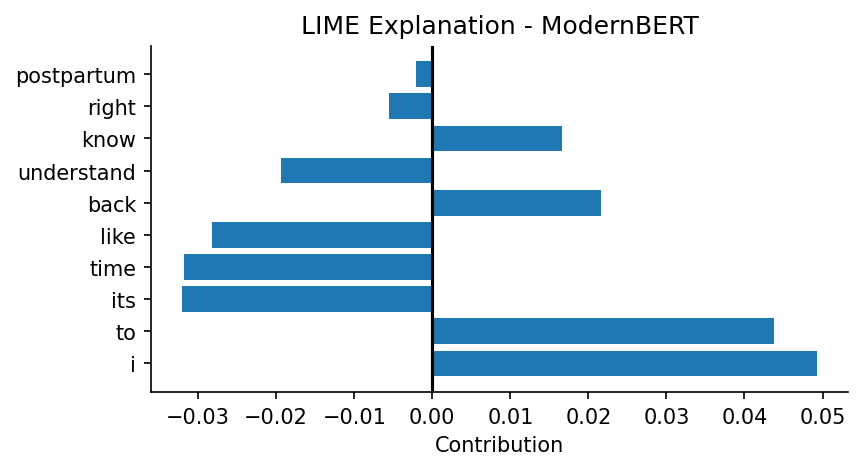

In [53]:
import matplotlib.pyplot as plt

words, scores = zip(*exp.as_list())

plt.figure(figsize=(6,3))
plt.barh(words, scores)
plt.axvline(0, color="black")
plt.title("LIME Explanation - ModernBERT")
plt.xlabel("Contribution")
plt.show()